# Supervised Learning - Foundations Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [94]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==2.2.2 -q --user

In [95]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [96]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading the dataset

In [97]:
# importing the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
rcell = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/used_device_data.csv')

## Data Overview

- Observations
- Sanity checks

In [99]:
# displaying the first few rows of the dataset
rcell.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


* All the columns seem to have appropriate data types.

In [100]:
# checking the shape of the dataset
rcell.shape

(3454, 15)

- The dataset contains 3454 rows and 15 columns.

In [101]:
# checking the data types of the columns for the dataset.
rcell.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

- There are 11 numeric (float and int type) and 4 string (object type) columns in the data.
- The target variable is the normalized_used_price, which is of float type.
- There are several columns with missing values - main_camera_mp, selfie_camera_mp, int_memory, ram, battery, and weight.

In [102]:
# getting statistical summary of the dataset
rcell.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


- Android is the most occurring type of os.
- Most of the device do not have 5g available.


In [103]:
# checking for duplicate values
rcell.duplicated().sum()

0

- There are no duplicate values in the data.

In [104]:
# checking for missing values
rcell.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


- There are missing values in several columns.

In [105]:
# creating a copy of the data so that original data remains unchanged
df = rcell.copy()

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

In [171]:
# defining functions needed to carry out the EDA
def histogram_boxplot(data, feature, figsize=(15,10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,  # Adjust to your preference
    )  # Create the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # Boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram


In [180]:
# defining a function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            ) # percentage of each class of the category
        else:
            label = p.get_height() # count of each level of the category

        x = p.get_x() + p.get_width() / 2 # width of the plot
        y = p.get_height() # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

        plt.show()  # show the plot

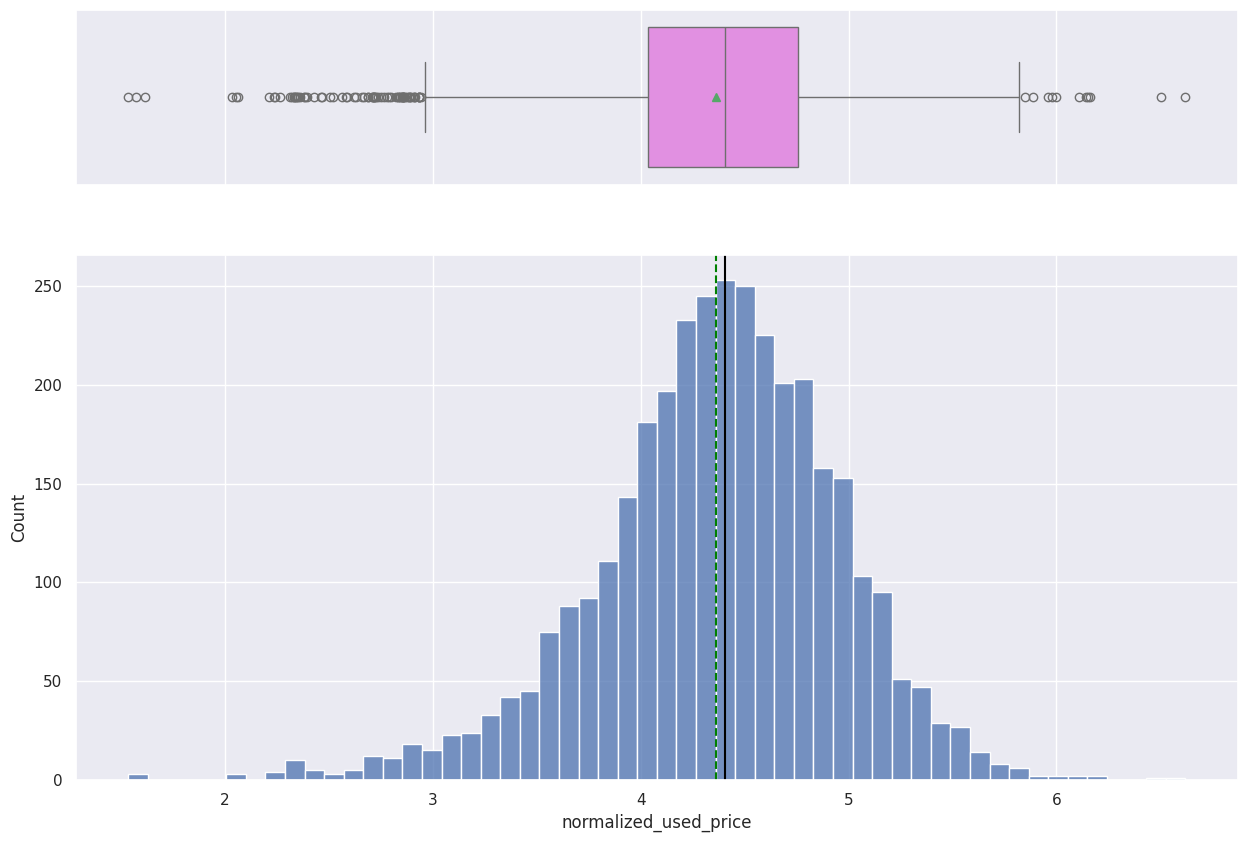

In [173]:
histogram_boxplot(df, 'normalized_used_price')

- The normalized used price is close to normally distributed and slightly left-skewed.
- The average price is approximately 4.4 in euros.
- There are outliers on both ends of the distribution.

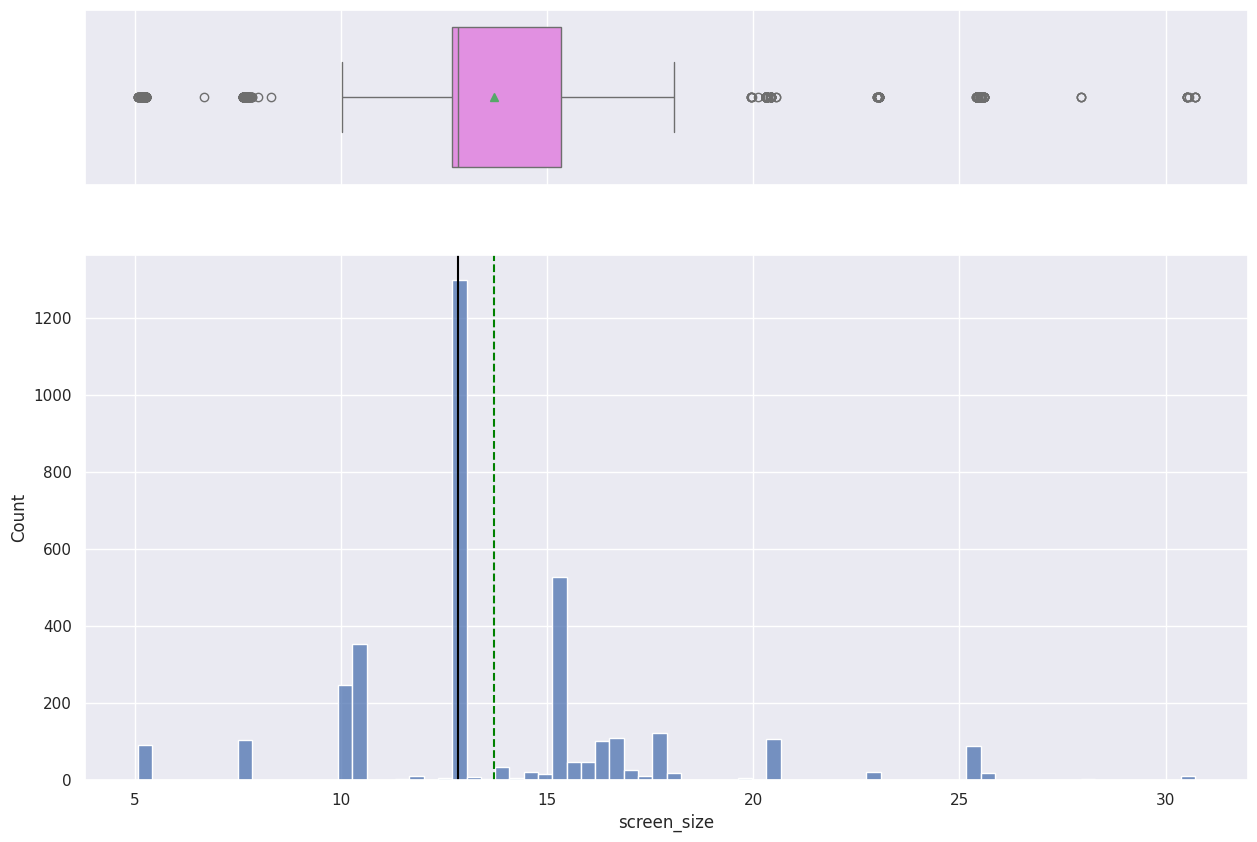

In [174]:
histogram_boxplot(df, 'screen_size')

- The distribution for screen size is right skewed with a median value of approximately 13.
- There are significant number of outliers.

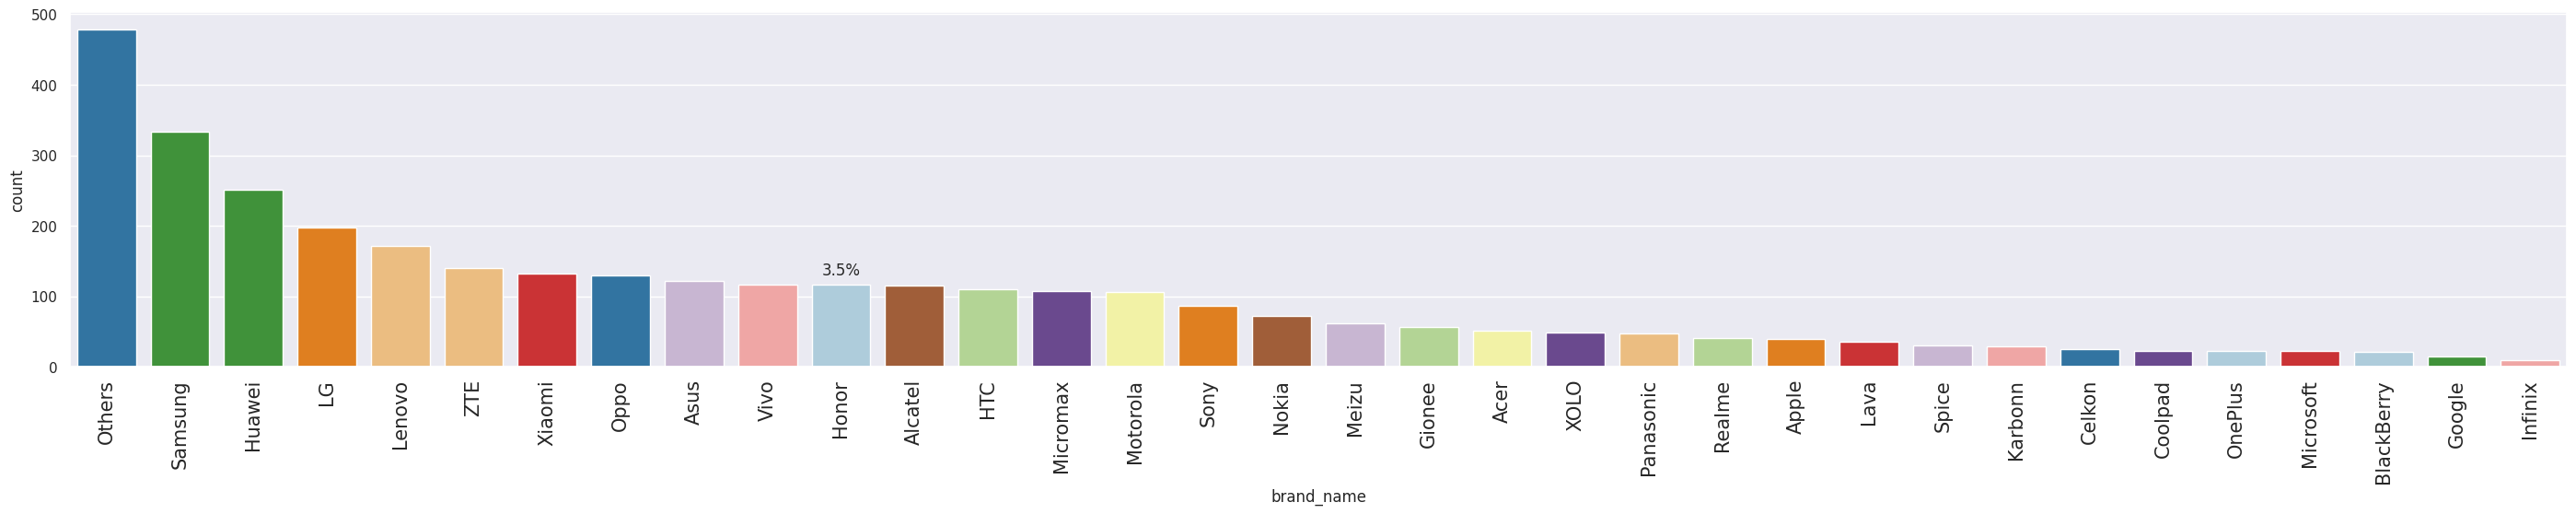

In [181]:
# obtaining the number of phones and tablets across different brands with screen size larger than 6 inches
above_6 = df[df['screen_size'] > 6]
labeled_barplot(above_6, 'brand_name', perc=True)

* Except for Others and Samsung, the rest of the brands have insignificant percentage of phones and tablets with screen size greater than 6 inches.

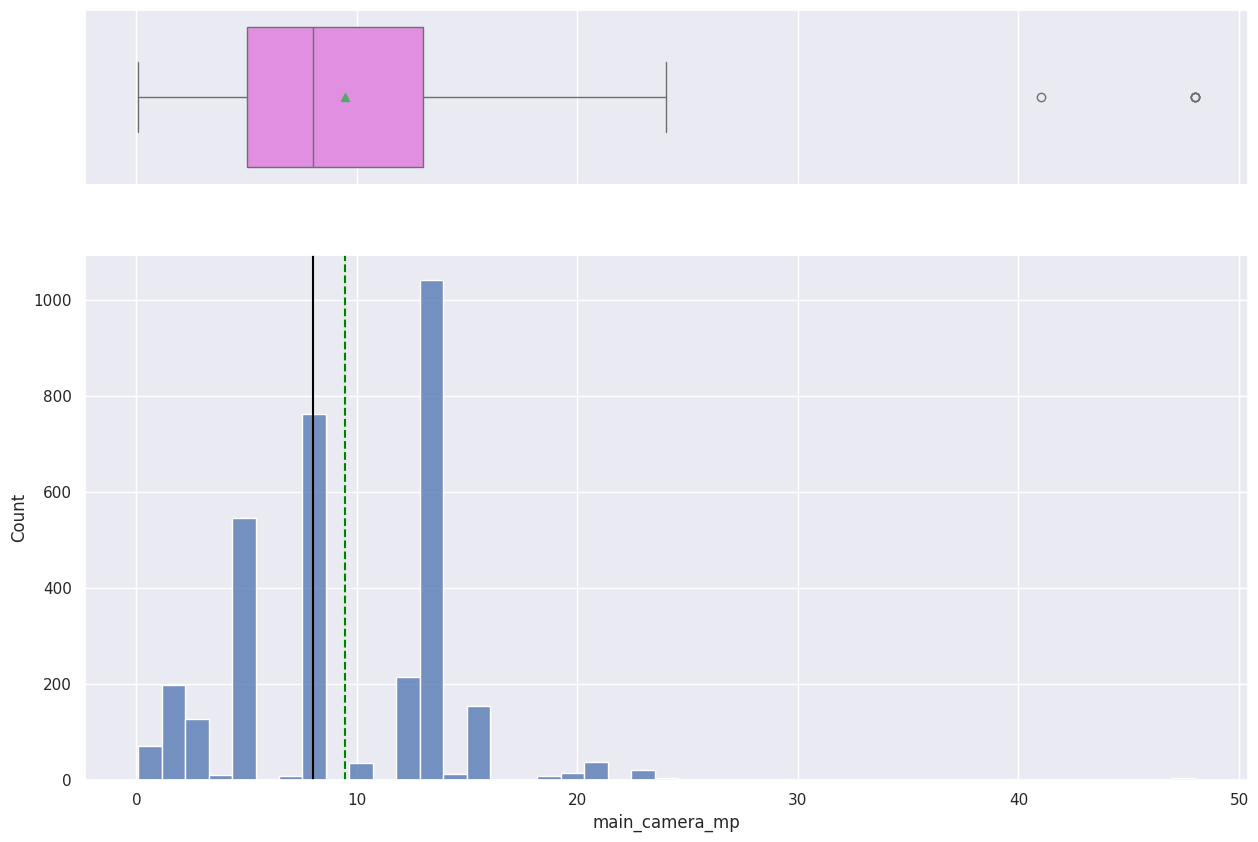

In [111]:
histogram_boxplot(df, 'main_camera_mp')

- The distribution for main camera resolution is right skewed with outliers above the maximum value.
- The median value is approximately 9 mp.

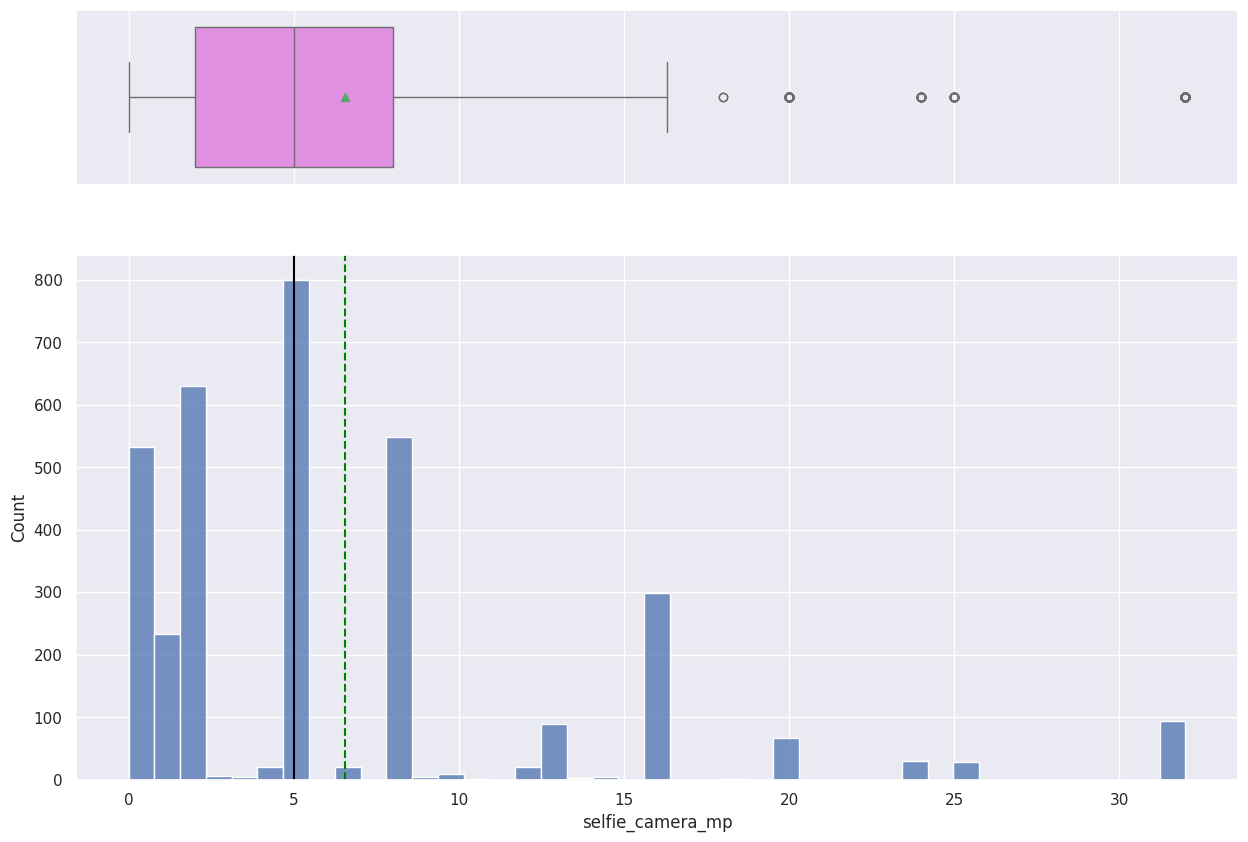

In [112]:
histogram_boxplot(df, 'selfie_camera_mp')

- The distribution for selfie camera resolution is right skewed with outliers above the maximum value.
- The median value is approximately 5 mp.

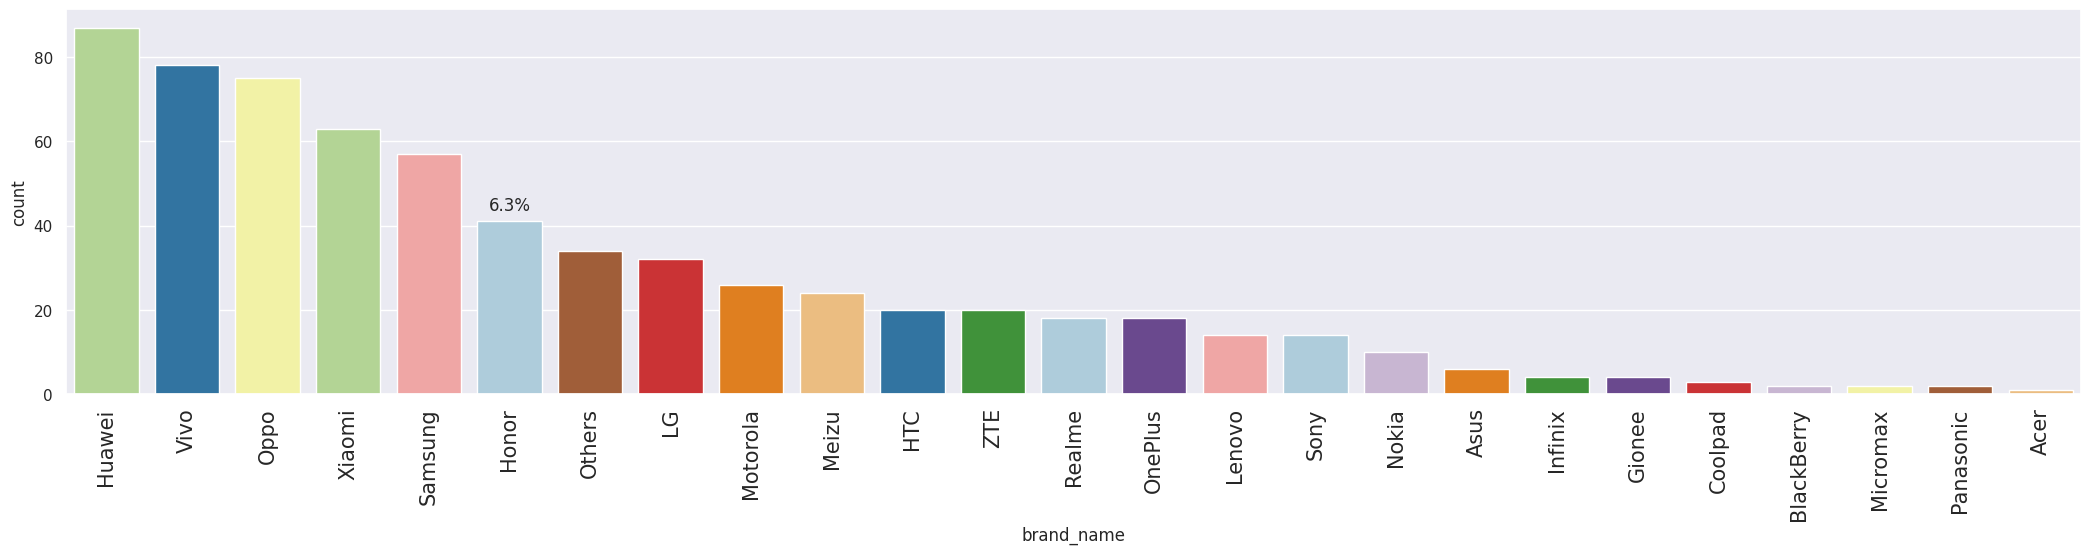

In [182]:
# getting distribution of devices offering greater than 8 MP selfie cameras across brands
above_8 = df[df['selfie_camera_mp'] > 8]
labeled_barplot(above_8, 'brand_name', perc=True)

* The top three brands offering greater than 8 MP selfie cameras are Huawei, Vivo and Oppo.

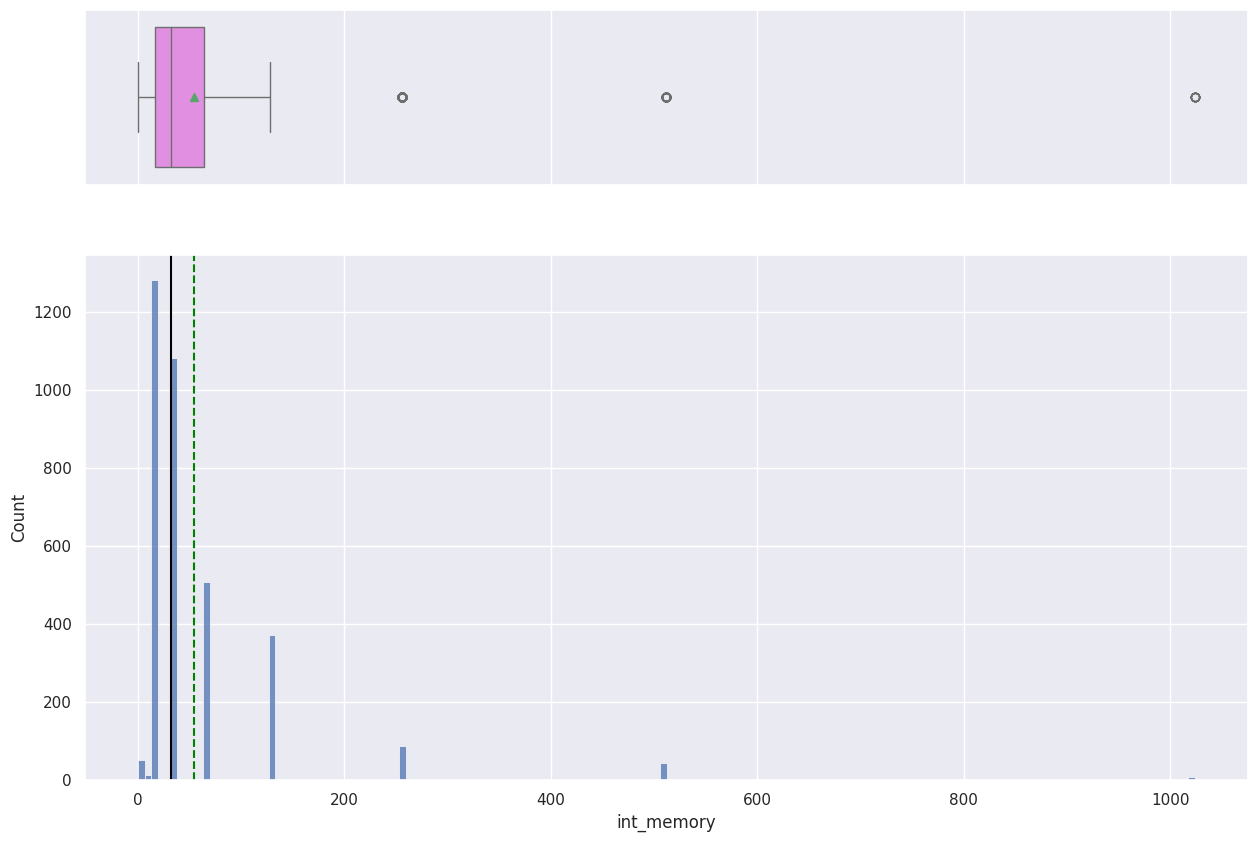

In [114]:
histogram_boxplot(df, 'int_memory')

- The distribution for internal memory (ROM) is right skewed with outliers above the maximum value.

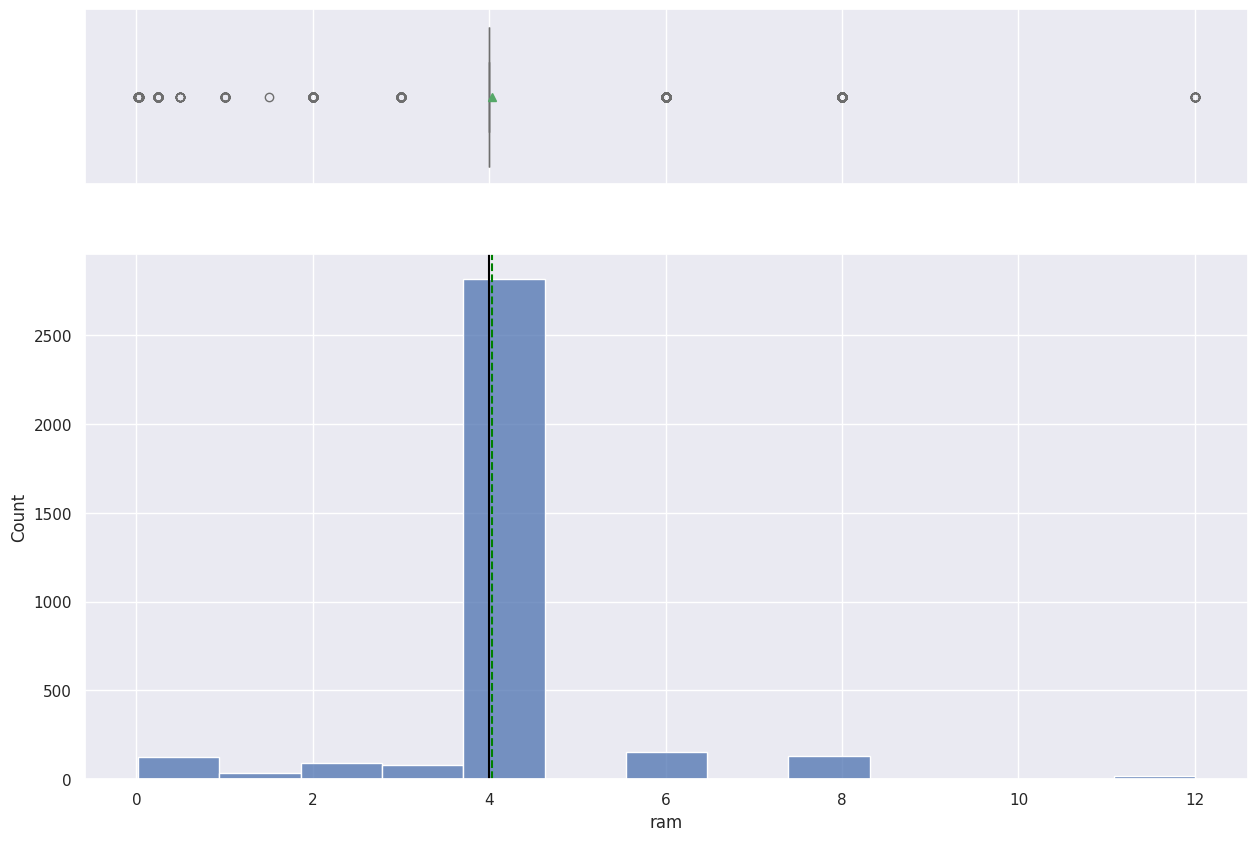

In [115]:
histogram_boxplot(df, 'ram')

- The distribution for RAM memory is highly concentrated on mean and median with outliers on both ends of the distribution.
- The median value is 4 GB.

In [116]:
# let's group the devices by brands and determine the amount of Ram
df.groupby('brand_name')['ram'].mean().sort_values(ascending=False)

,ram
brand_name,
OnePlus,6.363636
Oppo,4.961240
Vivo,4.756410
Huawei,4.655378
Honor,4.603448
Xiaomi,4.583333
Google,4.533333
Meizu,4.451613
Samsung,4.199413


* On average OnePlus has the largest RAM and Celkon has the smallest RAM among different brands.

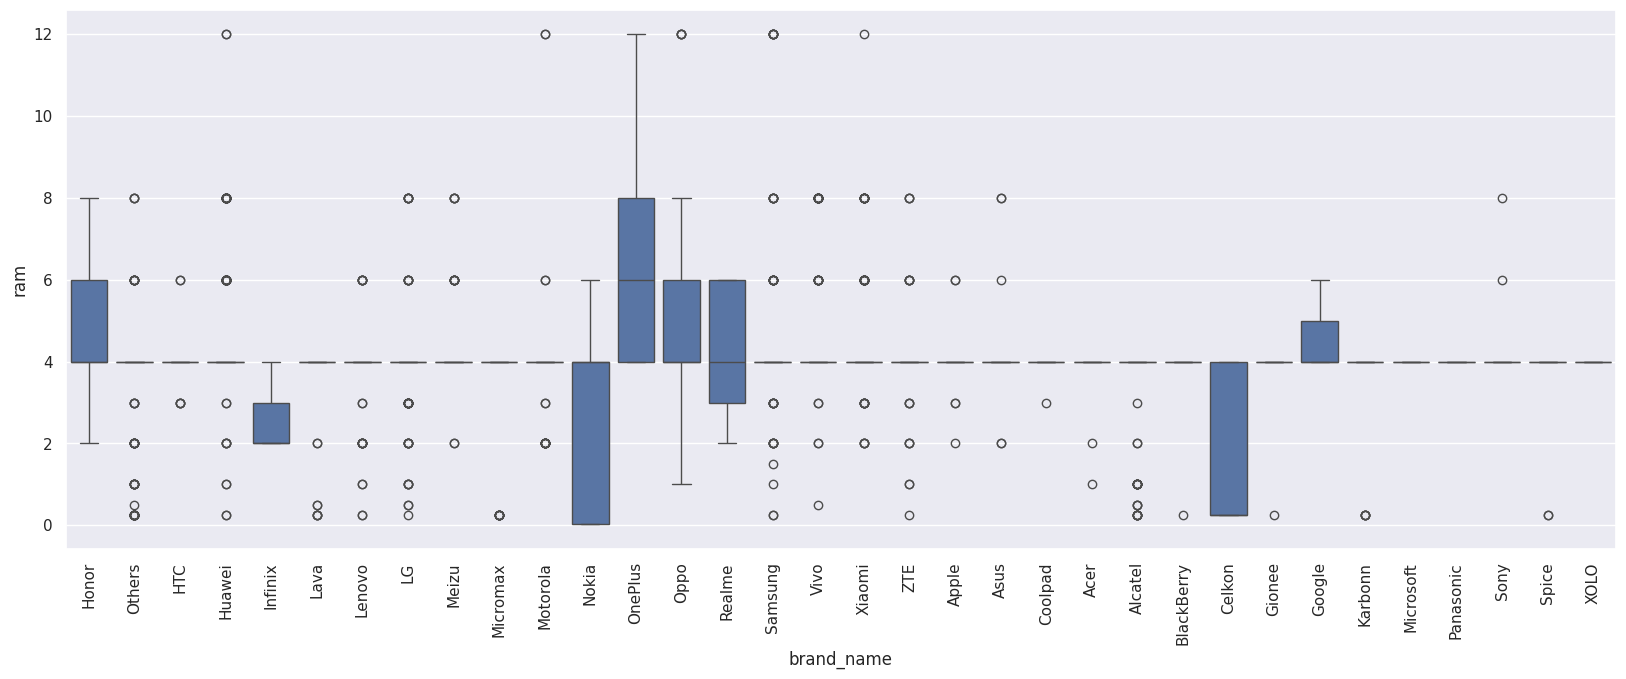

In [117]:
plt.figure(figsize=(20,7))
sns.boxplot(data=df, x='brand_name', y='ram')
plt.xticks(rotation=90)
plt.show()

* OnePlus has the largest amount of RAM with at least 4 GB.
* 75% of Honor and Oppo devices have at least 4 GB of RAM.
* In contrast, most of Infinix, Nokia, and Celkon devices have 4 GB or less of RAM.


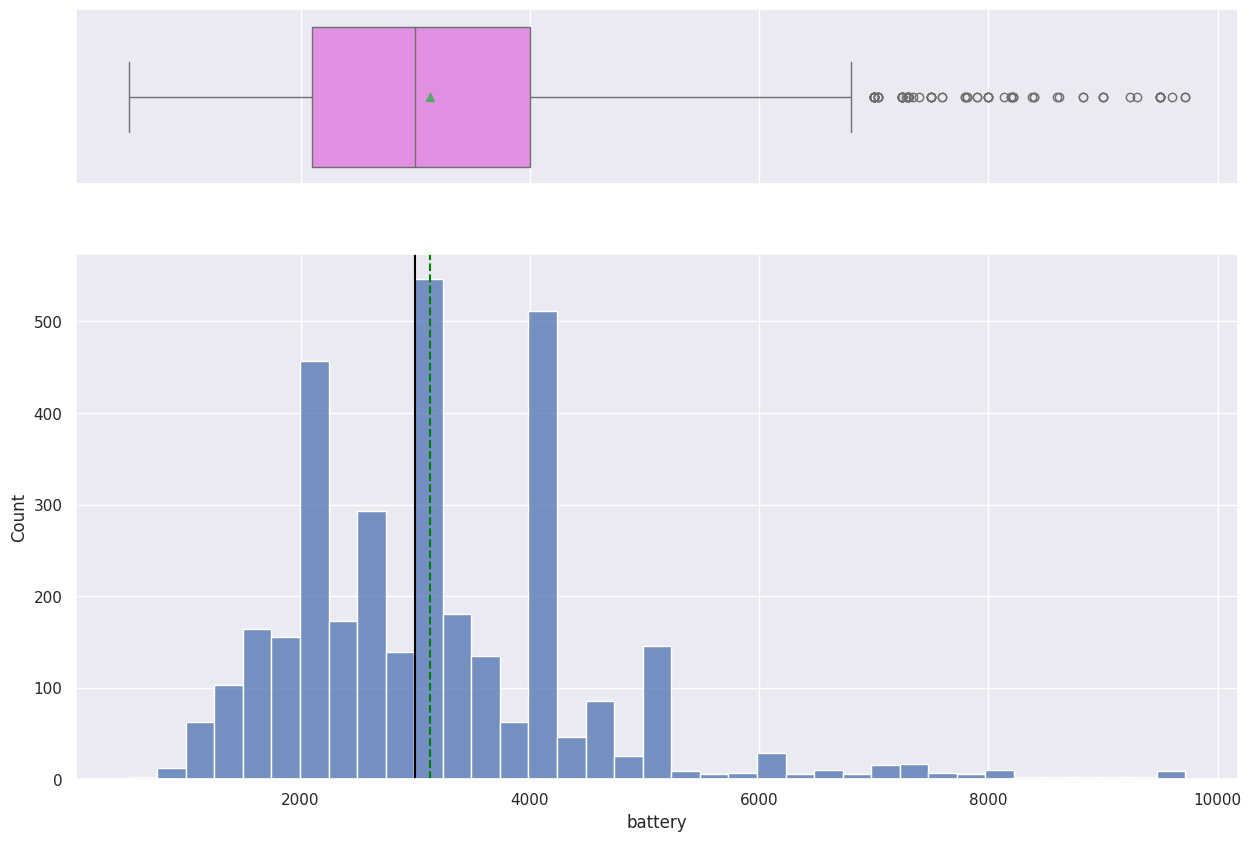

In [118]:
histogram_boxplot(df, 'battery')

- The distribution for battery is slightly right skewed with outliers above the maximum value.
- The median value is approximately 3000 mAh.

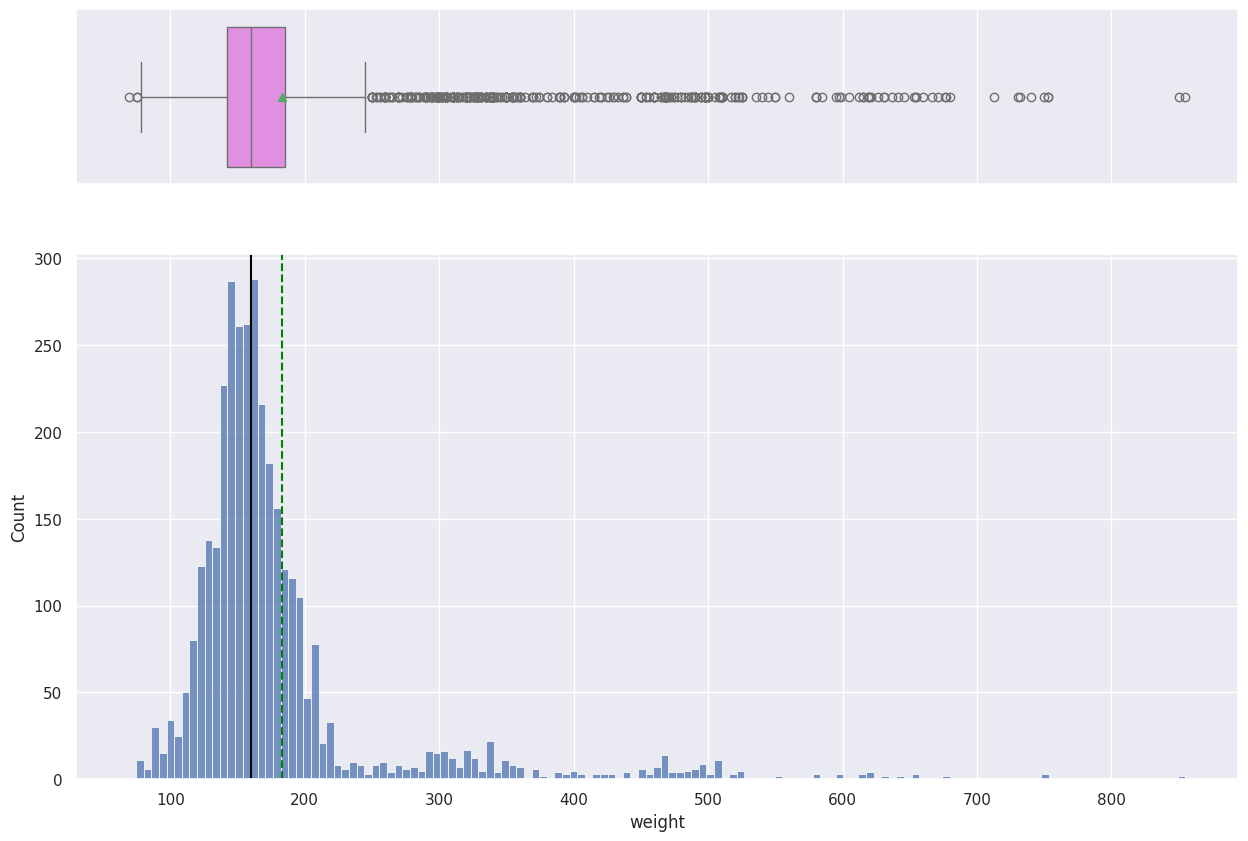

In [119]:
histogram_boxplot(df, 'weight')

- The distribution for weight is right skewed with outliers above the maximum value.
- The median value is approximately 165 grams.

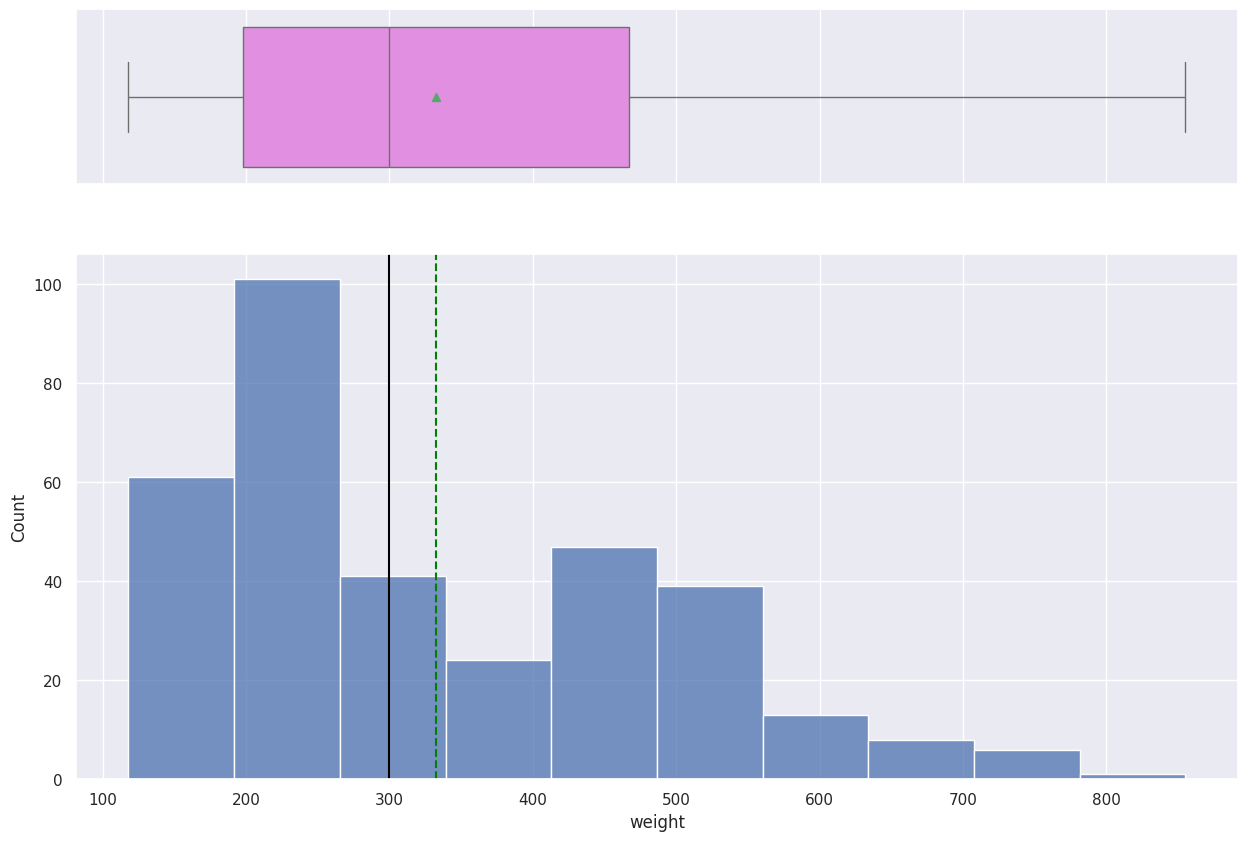

In [120]:
above_4500 = df[df['battery'] > 4500]
histogram_boxplot(above_4500, 'weight')

* For phones and tablets offering large batteries (more than 4500 mAh), the distribution is right skewed with the median of 300 grams.

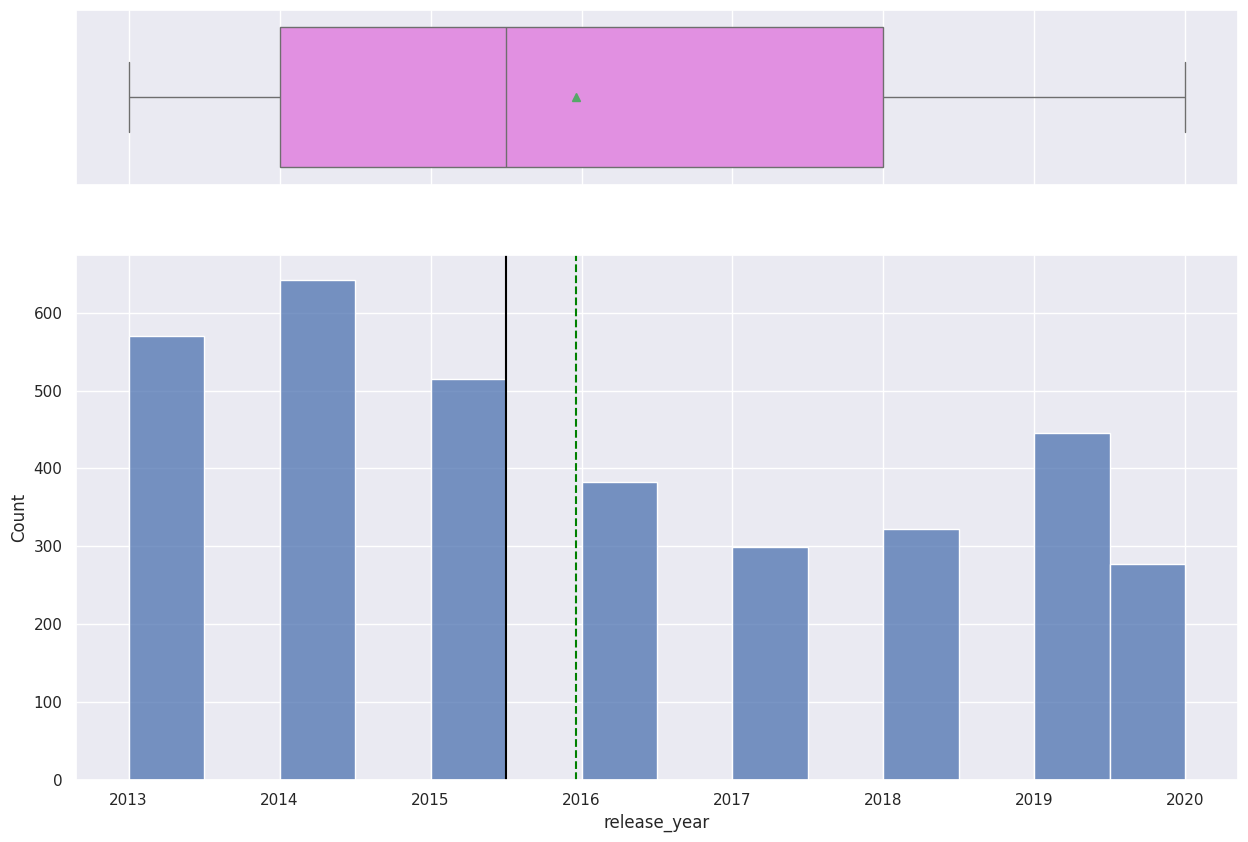

In [121]:
histogram_boxplot(df, 'release_year')

- The distribution for release year is right skewed with no outliers.
- The median value is 2015.5.

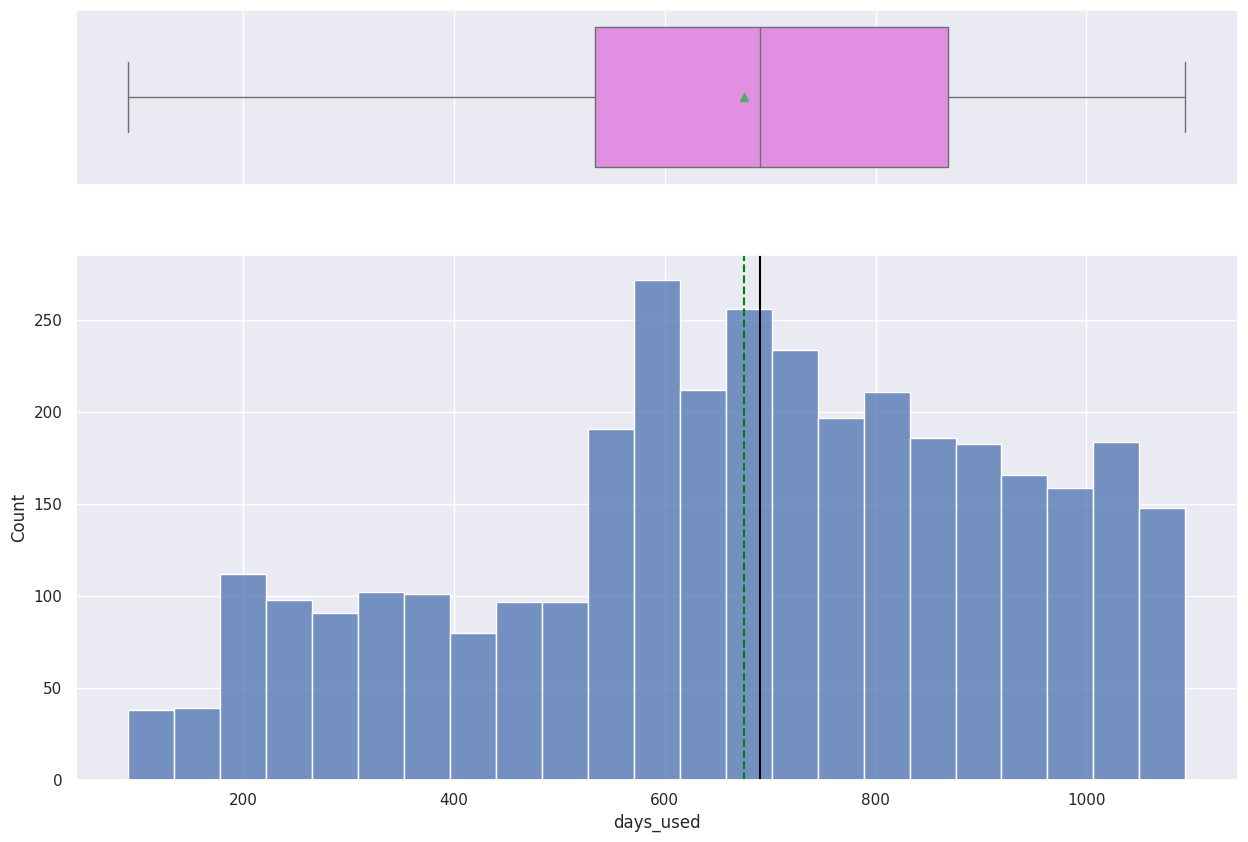

In [122]:
histogram_boxplot(df, 'days_used')

- The distribution for the numer of days used is slightly left skewed with no outliers.
- The median value is approximately 690 days.

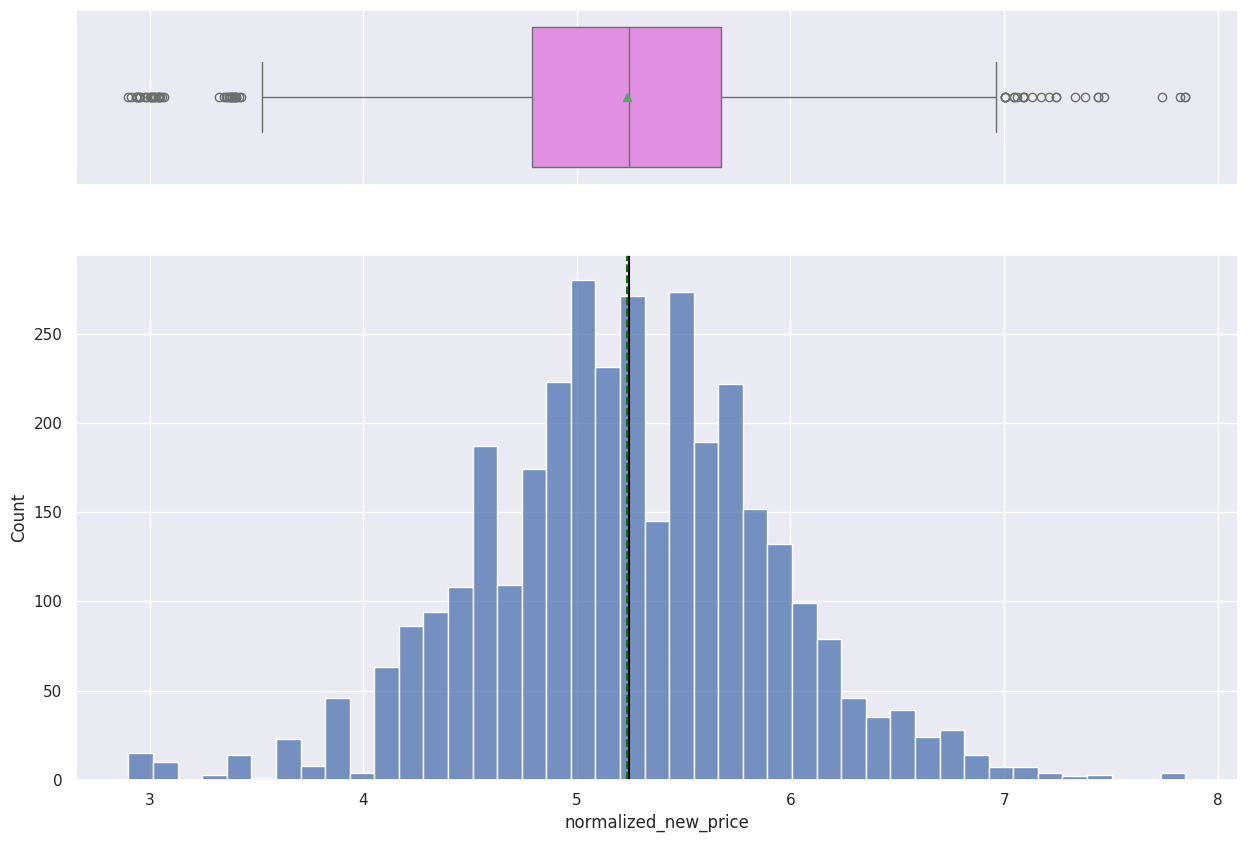

In [123]:
histogram_boxplot(df, 'normalized_new_price')

- The distribution for normalized price of a new device is close to normally distributed with outliers on both ends of the distribution.
- The average price is approximately 5.3 in euros.

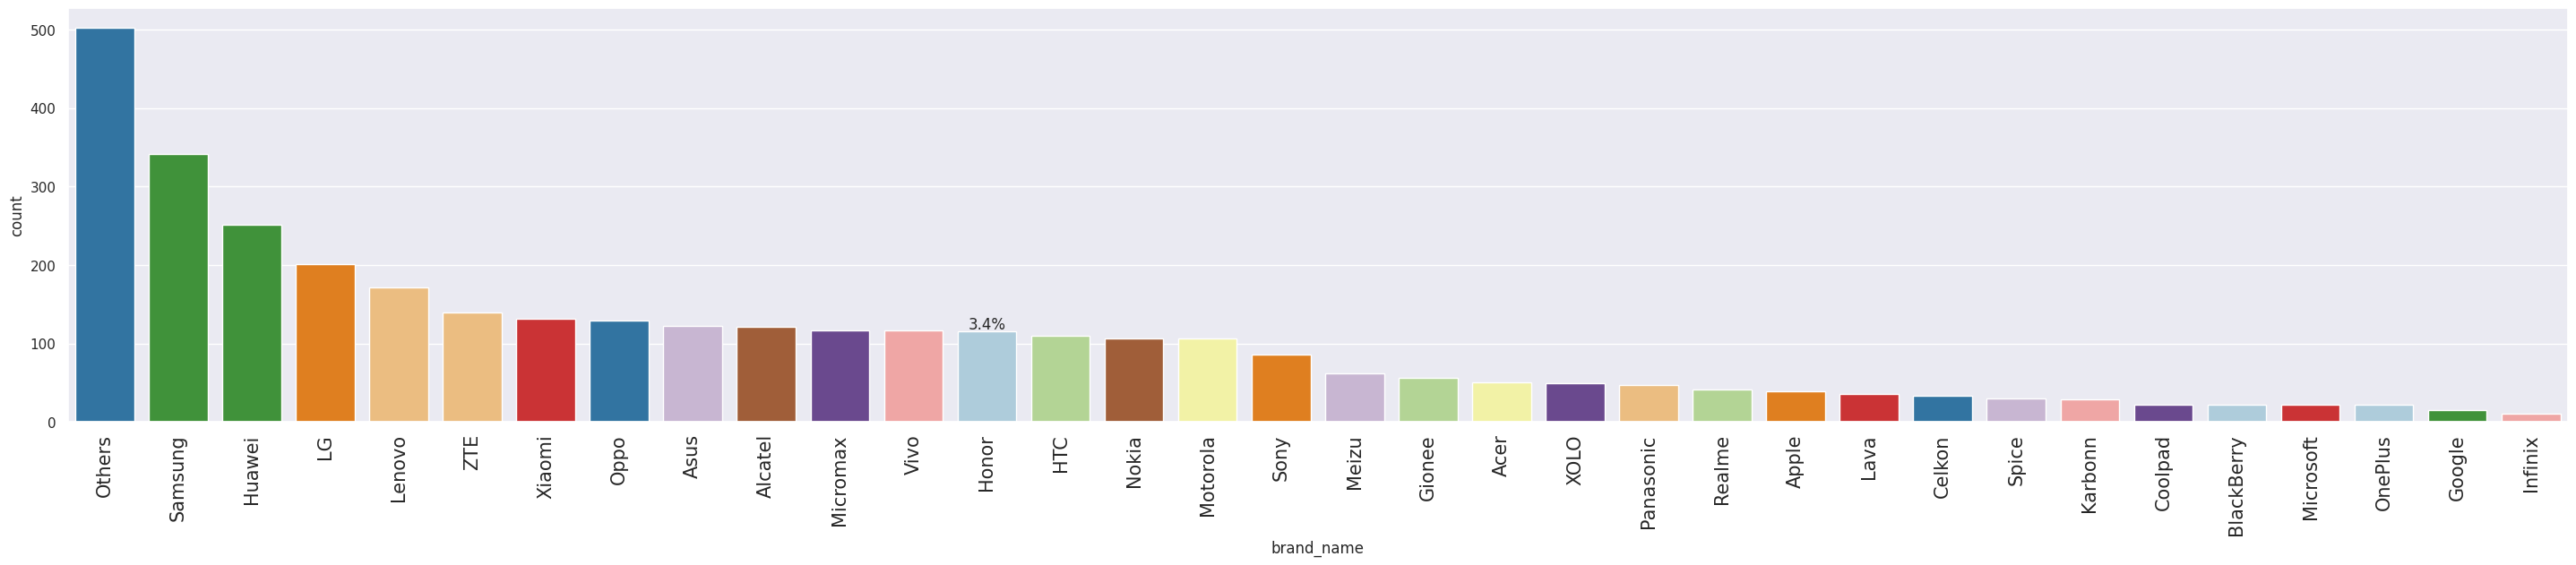

In [124]:
labeled_barplot(df, 'brand_name', perc=True)

* Others have the highest percentage among the brands.
* Except for Others and Samsung, all the other brands have less than 10% of the total devices.

---



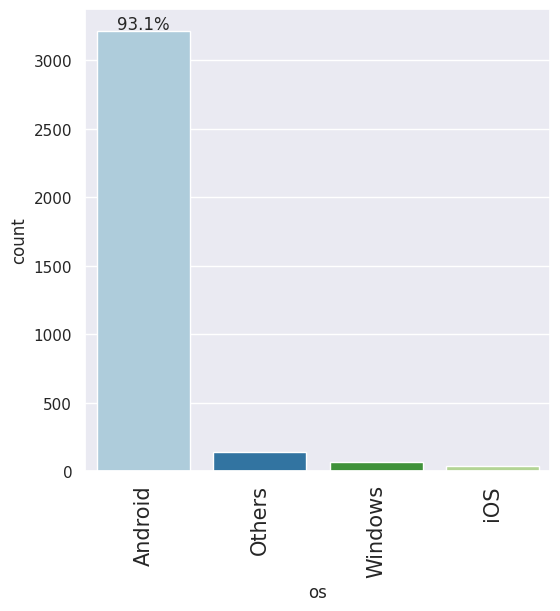

In [125]:
labeled_barplot(df, 'os', perc=True)

* Androids have the highest percentage of the total devices at 93.1%.
* The other 3 os's have insignificant percentage of the total devices.

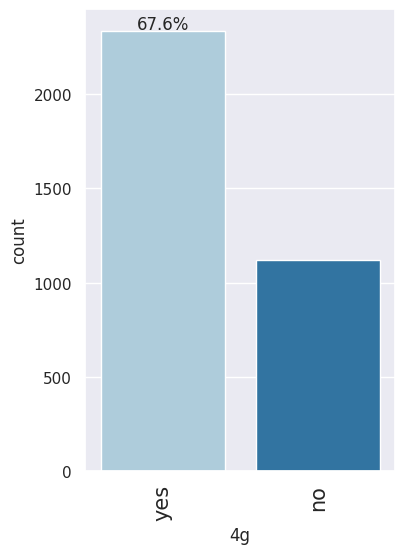

In [126]:
labeled_barplot(df, '4g', perc=True)

* 67.6% of the devices offer 4g.

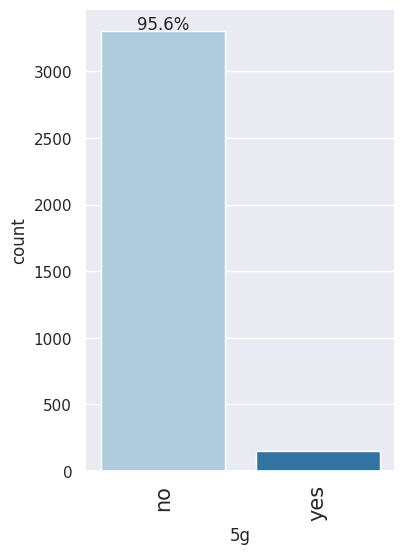

In [127]:
labeled_barplot(df, '5g', perc=True)

* Only 4.4% of the devices offer 5g.

In [128]:
# creating a list of numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# dropping realease_year from list of numerical columns as it is not numerical in nature
num_cols.remove("release_year")

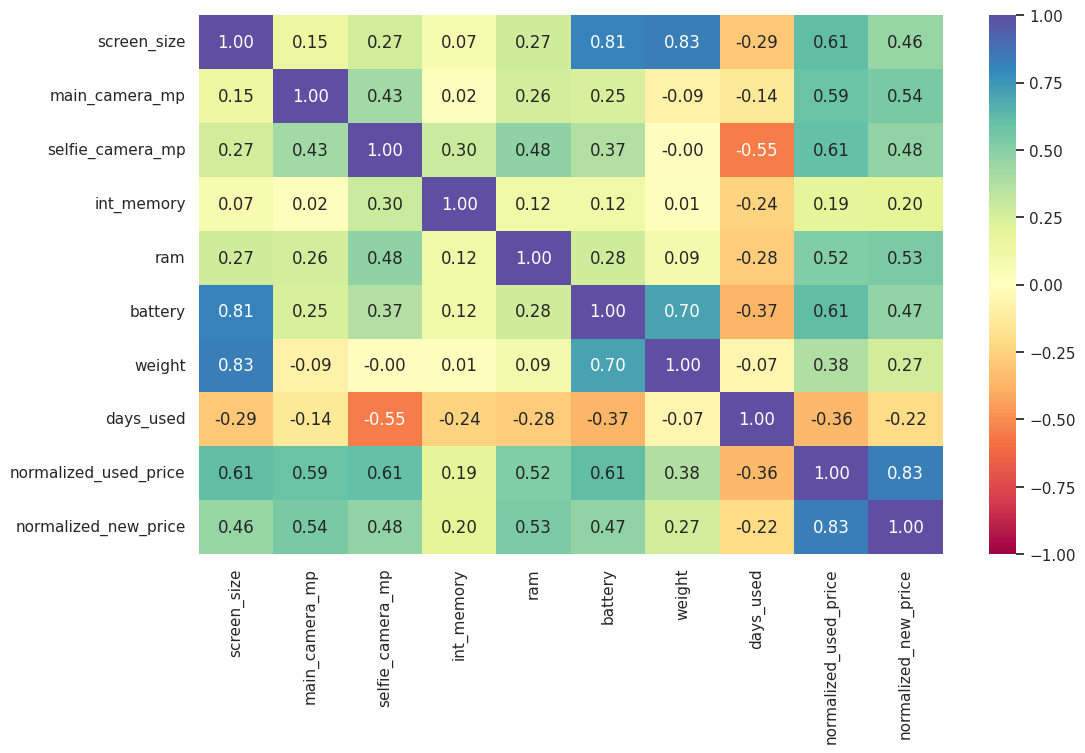

In [129]:
# plotting a heat map to identify any correlations among different variables
plt.figure(figsize=(12, 7))
sns.heatmap(df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* The normalized used price is highly correlated with normalized new price.
* The normalized used price is relatively correlated with screen size, main camera mp, selfie camera mp, and battery.
* The screen size is highly correlated with battery and weight.
* Battery is relatively correlated with weight.

## Data Preprocessing

### Missing Value Treatment

In [130]:
# checking missing values in the data set
df.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


Let's fix the missing values in the data.

- For the variable main_camera_mp and selfie_camera_mp, we will impute the missing values in each column with the median grouped by brands as both columns have skewed distributions.

In [160]:
# let's create a copy of the data to avoid changes to it.
df1 = df.copy()

In [161]:
df1["main_camera_mp"] = df1["main_camera_mp"].fillna(
    value=df1.groupby(['brand_name'])['main_camera_mp'].transform("median")
)
df1["selfie_camera_mp"] = df1["selfie_camera_mp"].fillna(
    value=df1.groupby(['brand_name'])['selfie_camera_mp'].transform("median")
)

df1.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,10
selfie_camera_mp,0
int_memory,4
ram,4
battery,6


- There are still 10 missing values in main_camera_mp column. We will impute the remaining missing values with the median of the total devices.

In [162]:
# let's impute the remaining 10 missing values in main_camera_mp column with the overall median value.
df1["main_camera_mp"] = df1["main_camera_mp"].fillna(
    value=df1["main_camera_mp"].median()
)
df1.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,4
ram,4
battery,6


- Since internal memory and RAM varies across different brands, we will imput the missing values with the median grouped by brands.
- As for the missing values for battery and weight, we will imput them with the median of the overall devices as they have skewed distribution.

In [163]:
# let's impute the remaining missing values for int_memory and ram with the median grouped by brands
# and those for battery and weight with the median of the overal devices.
df1["int_memory"] = df1["int_memory"].fillna(
    value=df1.groupby(['brand_name'])['int_memory'].transform("median")
)
df1["ram"] = df1["ram"].fillna(
    value=df1.groupby(['brand_name'])['ram'].transform("median")
)
df1["battery"] = df1["battery"].fillna(
    value=df1["battery"].median()
)
df1["weight"] = df1["weight"].fillna(
    value=df1["weight"].median()
)
df1.isnull().sum()


,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


* All the missing values have been treated.

### Feature Engineering

* Let's create a new feature called device_age by taking the difference between the most recent year (2021) and release_year.
* We will drop the original column once the new feature is created as the release_year is not numerical in nature.

In [164]:
# creating a new column called device_age by taking the difference between 2021 and release_year.
df1['device_age'] = 2021 - df1['release_year']

# dropping the original column release_year.
df1.drop('release_year', axis=1, inplace=True)
df1.head()


,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_used_price,normalized_new_price,device_age
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.307572,4.715100,1
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.162097,5.519018,1
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.111084,5.884631,1
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.135387,5.630961,1
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.389995,4.947837,1


### Outlier detection and treatment

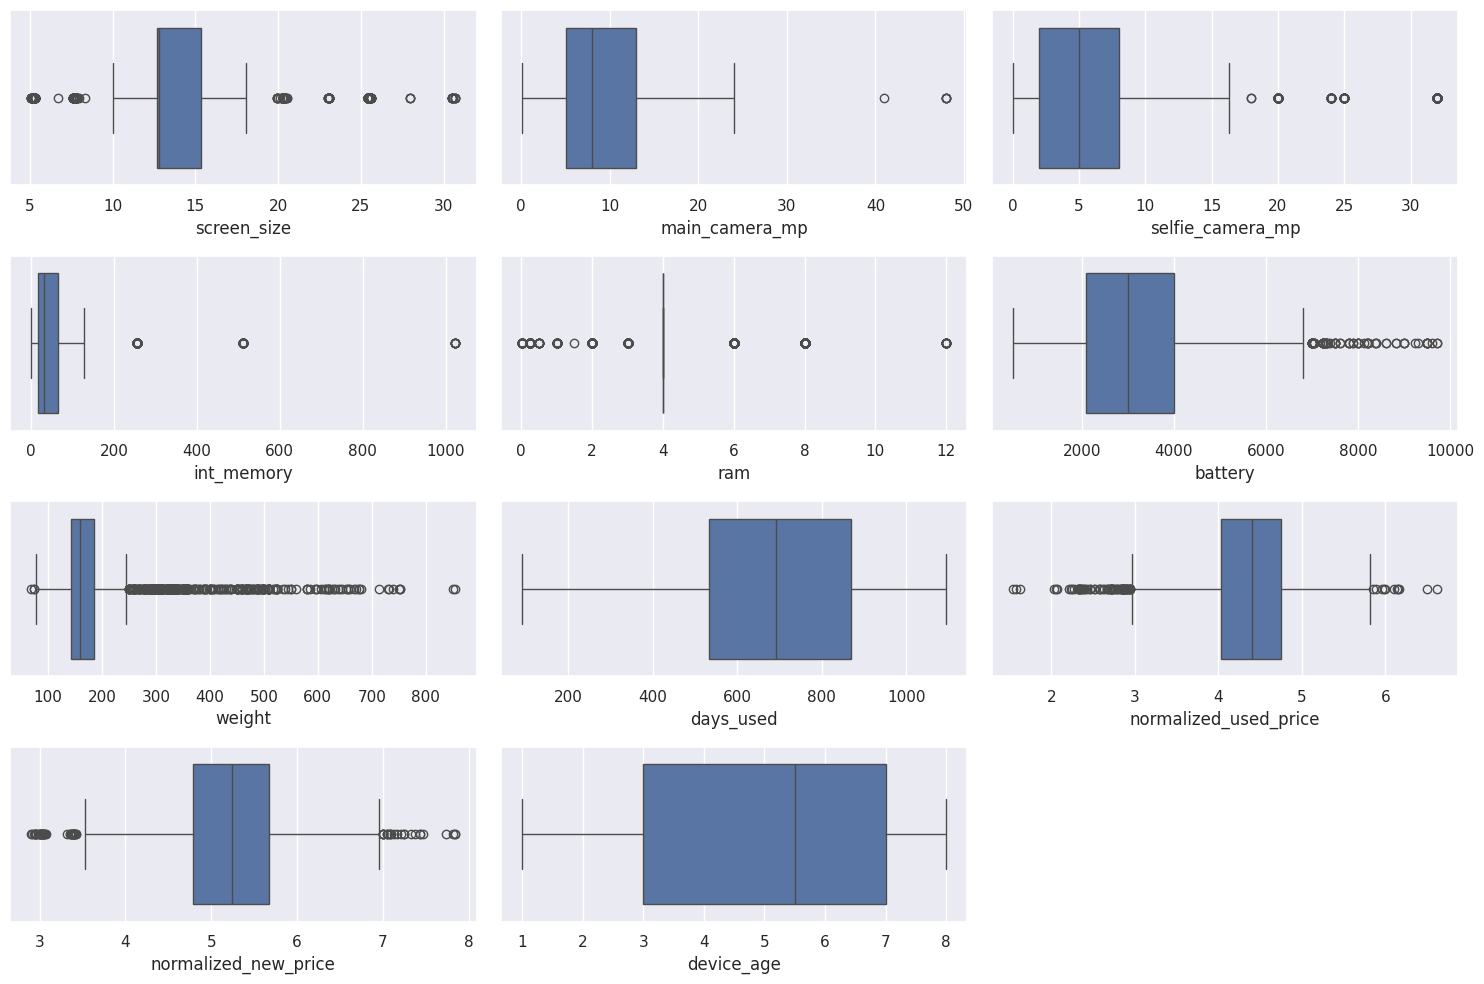

In [165]:
# outlier detection using boxplot
num_cols = df1.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout()
plt.show()

- There are quite a few outliers in the data.
- However, we will not treat them as they are proper values.

### Preparing data for modeling

- We want to predict the normalized price of used device.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.
- We will build a Linear Regression model using the train data and then check it's performance.

In [137]:
# defining X and y variables
X = df1.drop(['normalized_used_price'], axis=1)
y = df1['normalized_used_price']

print(X.head())
print(y.head())

  brand_name       os  screen_size   4g   5g  main_camera_mp  \
0      Honor  Android        14.50  yes   no            13.0   
1      Honor  Android        17.30  yes  yes            13.0   
2      Honor  Android        16.69  yes  yes            13.0   
3      Honor  Android        25.50  yes  yes            13.0   
4      Honor  Android        15.32  yes   no            13.0   

   selfie_camera_mp  int_memory  ram  battery  weight  days_used  \
0               5.0        64.0  3.0   3020.0   146.0        127   
1              16.0       128.0  8.0   4300.0   213.0        325   
2               8.0       128.0  8.0   4200.0   213.0        162   
3               8.0        64.0  6.0   7250.0   480.0        345   
4               8.0        64.0  3.0   5000.0   185.0        293   

   normalized_new_price  device_age  
0              4.715100           1  
1              5.519018           1  
2              5.884631           1  
3              5.630961           1  
4              4

In [138]:
# let's add the intercept to data
X = sm.add_constant(X)

In [139]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,...,False,False,False,False,False,False,False,False,True,False
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,...,False,False,False,False,False,False,False,False,True,True
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,...,False,False,False,False,False,False,False,False,True,True
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,...,False,False,False,False,False,False,False,False,True,True
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,...,False,False,False,False,False,False,False,False,True,False


In [140]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127.0,4.715100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325.0,5.519018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162.0,5.884631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345.0,5.630961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293.0,4.947837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [141]:
# splitting the data in 70:30 ratio for train to test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)


In [142]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 2417
Number of rows in test data = 1037


## EDA

- It is a good idea to explore the data once again after manipulating it.

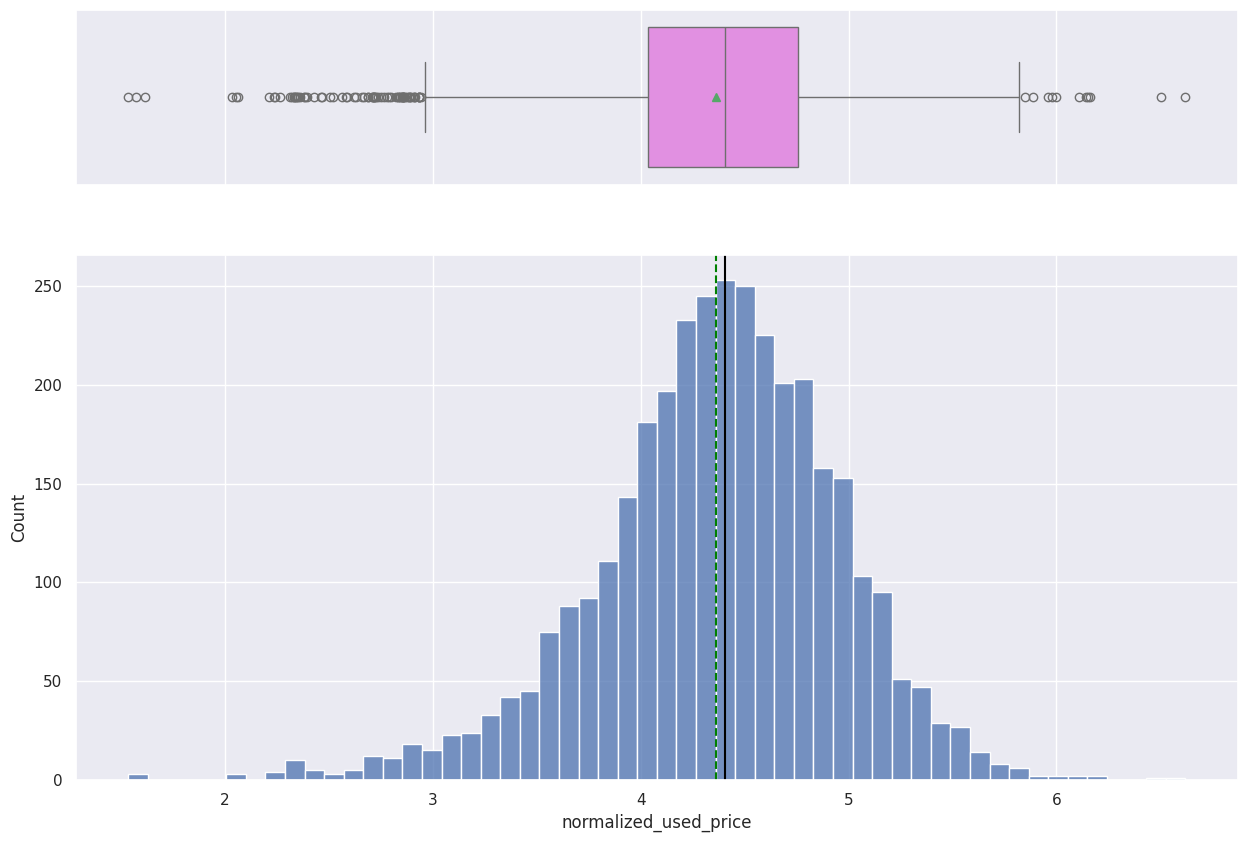

In [143]:
# let's run the functions for visualizing the data one more time
histogram_boxplot(df1, 'normalized_used_price')

*	The normalized used price is close to normally distributed and slighted left-skewed, which is almost identical to the distribution prior to data manipulation.
*	There are outliers on both ends of the distribution.


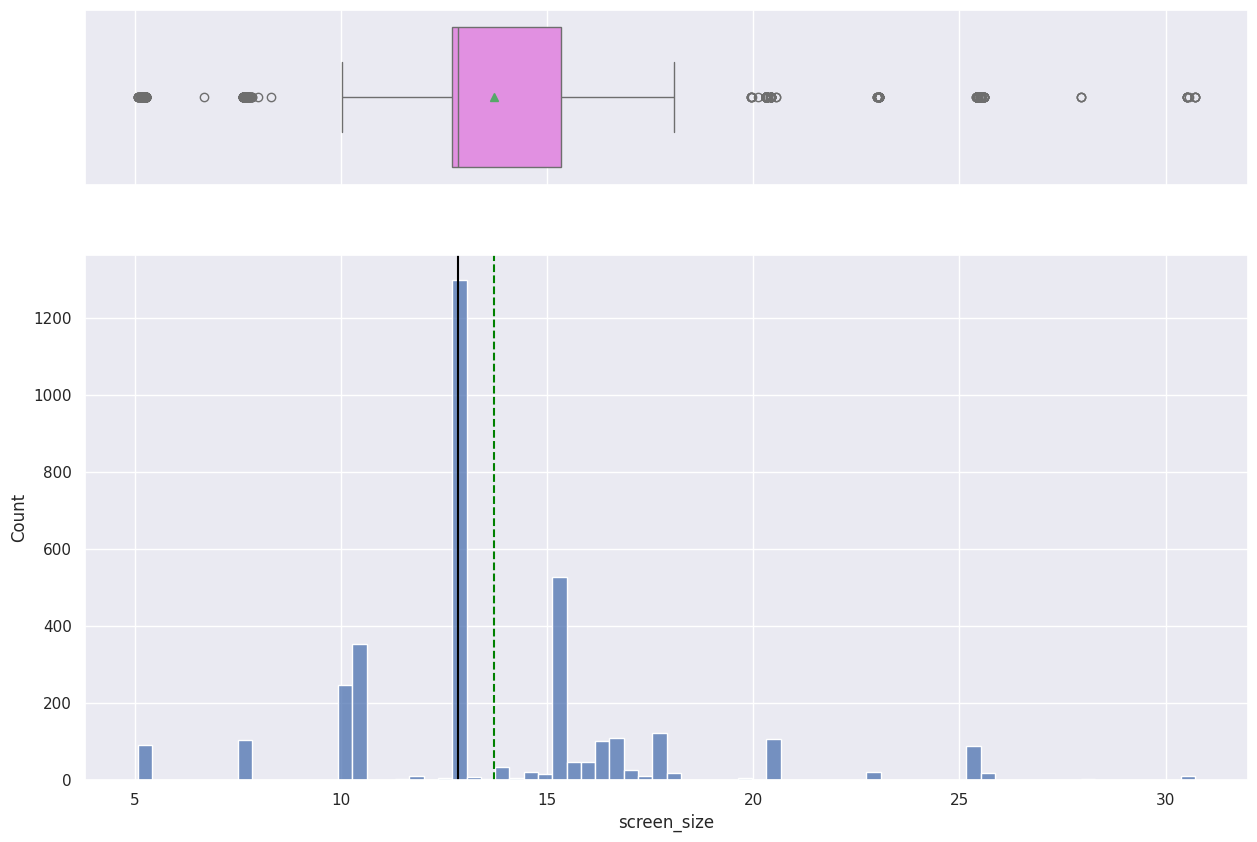

In [144]:
histogram_boxplot(df1, 'screen_size')

* The distribution for screen size is right skewed with a median value of approximately 13.

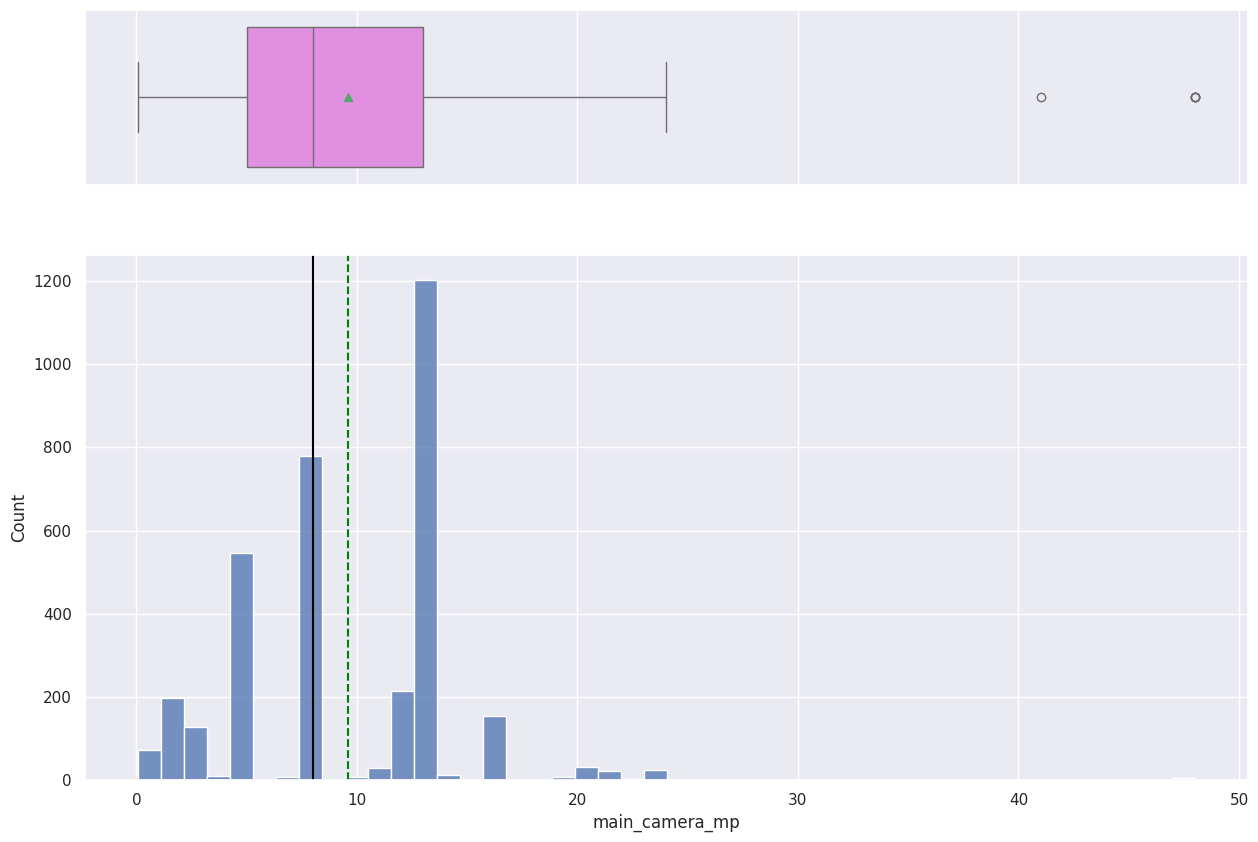

In [145]:
histogram_boxplot(df1, 'main_camera_mp')

* The distribution for main camera resolution is right skewed with outliers above the maximum value.
* The median value is approximately 9 mp.

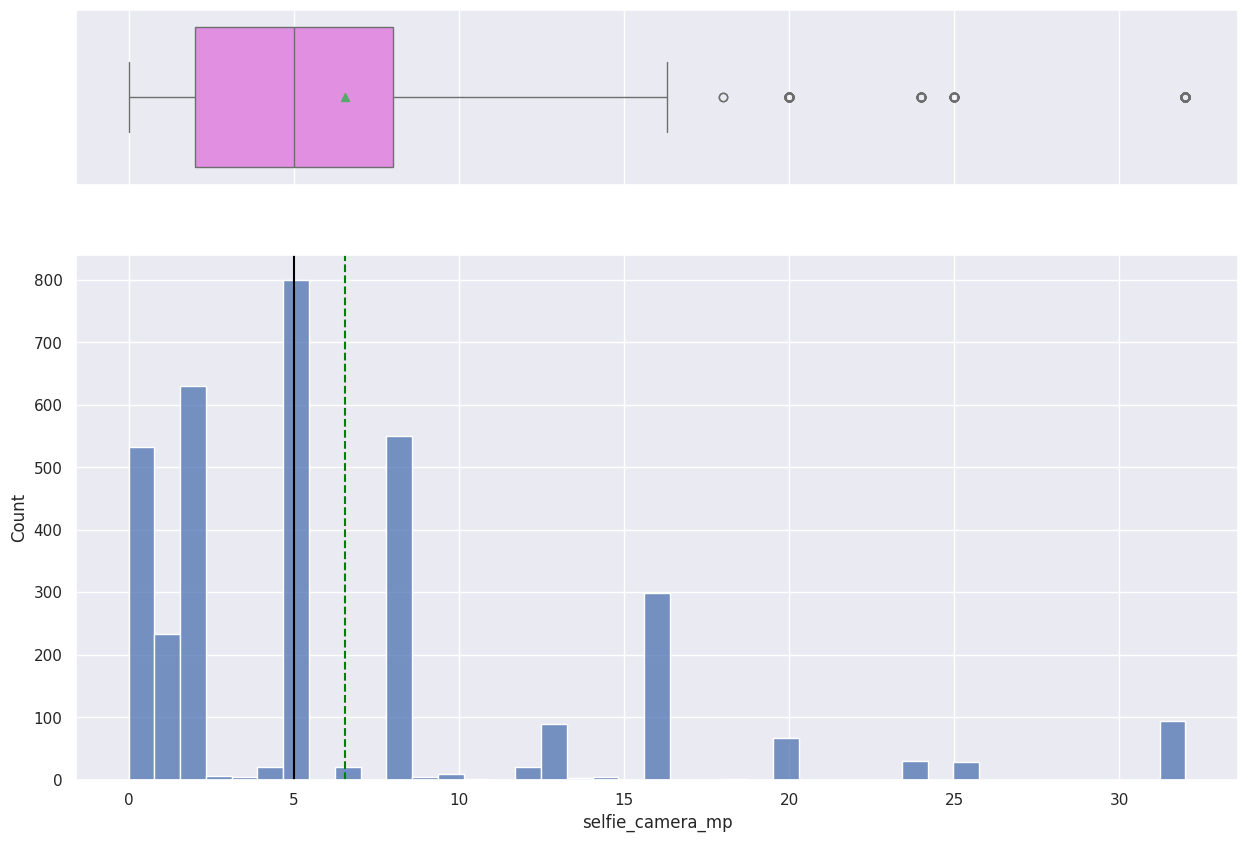

In [146]:
histogram_boxplot(df1, 'selfie_camera_mp')

* The distribution for selfie camera resolution is right skewed with outliers above the maximum value.
* The median value is approximately 5 mp.

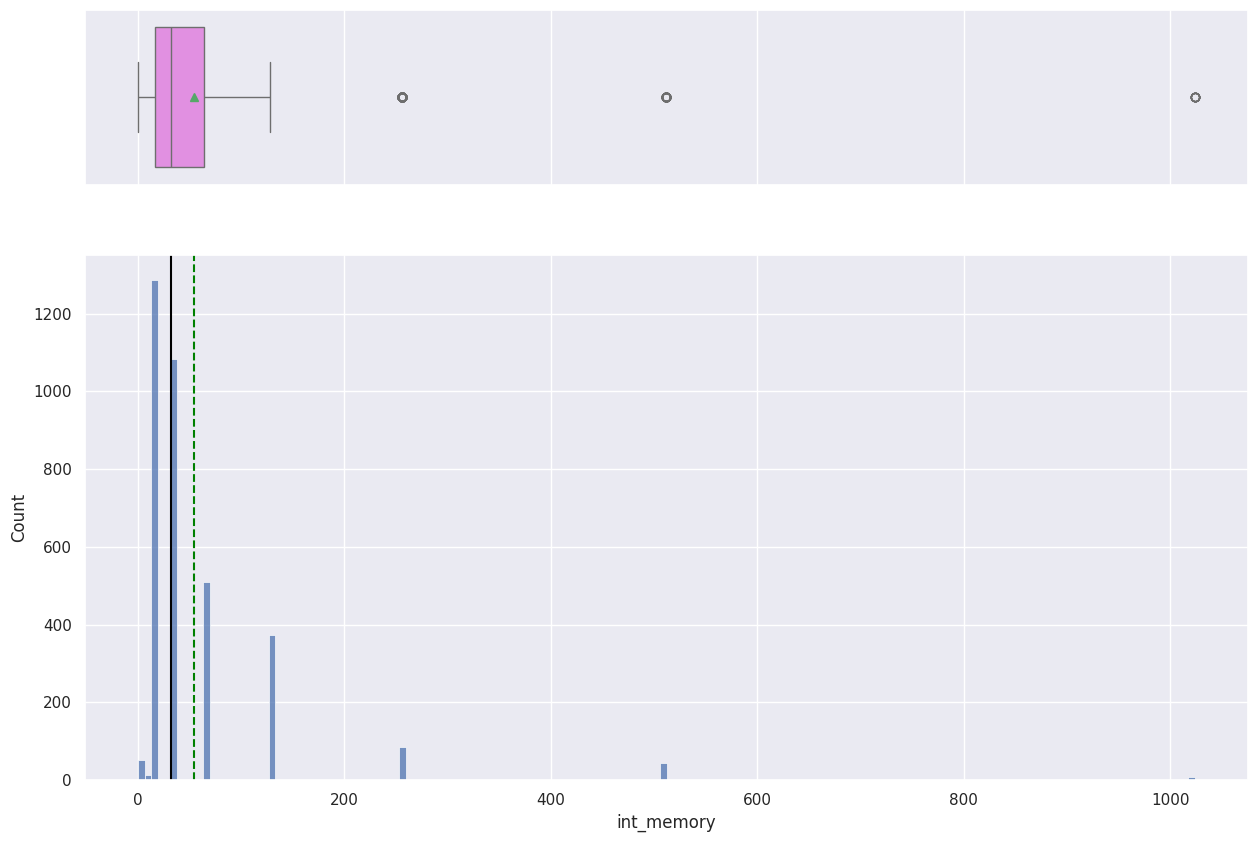

In [147]:
histogram_boxplot(df1, 'int_memory')

* The distribution for internal memory (ROM) is right skewed with outliers above the maximum value.

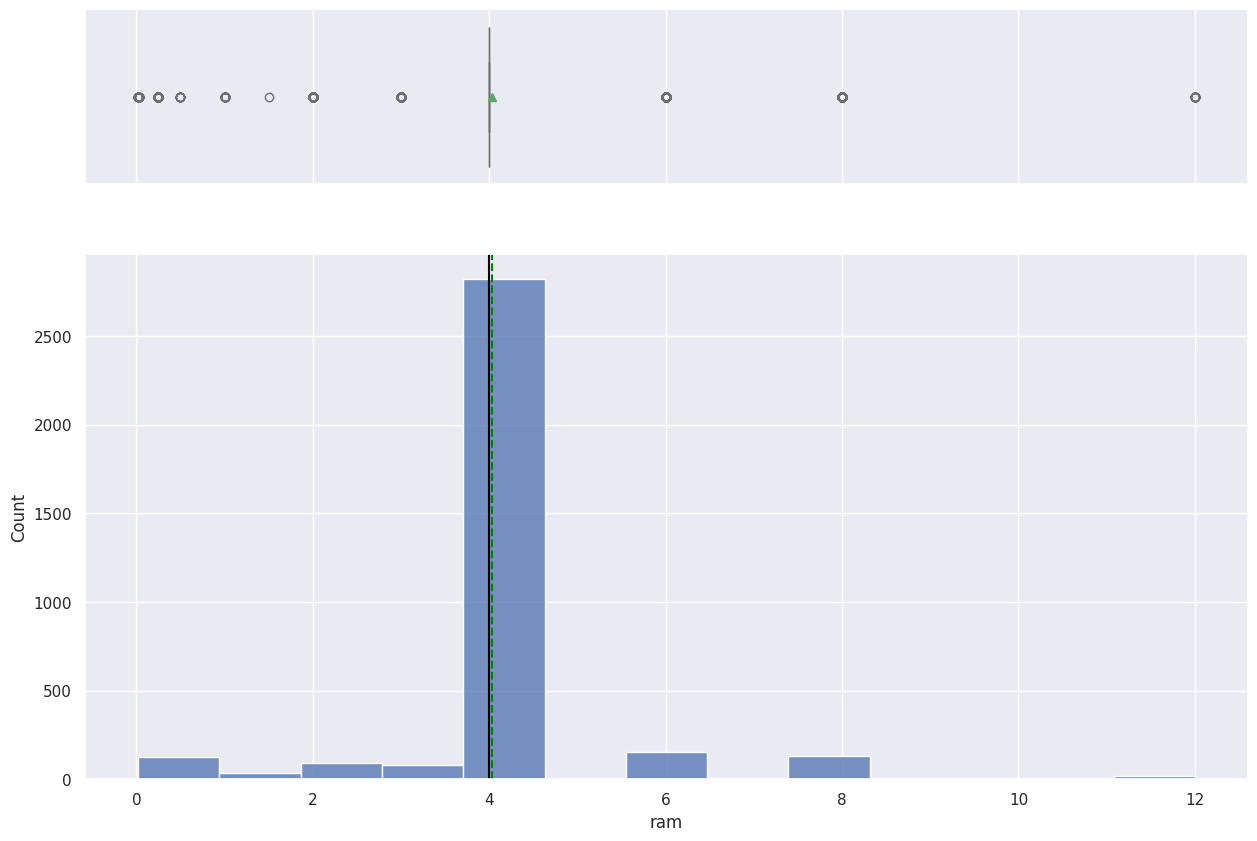

In [148]:
histogram_boxplot(df1, 'ram')

* The distribution for RAM memory is highly concentrated on median and mean with outliers on both ends of the distribution.
* The median value is 4 GB.


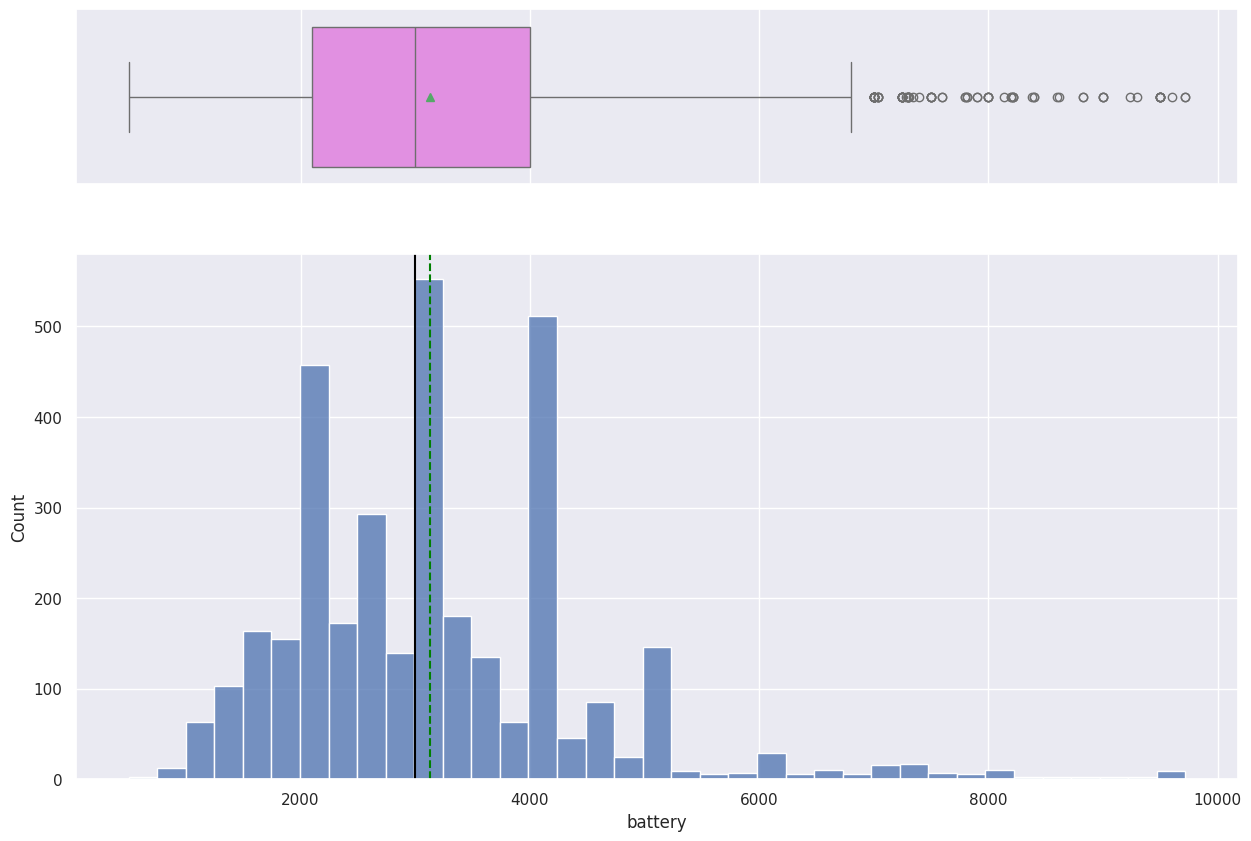

In [149]:
histogram_boxplot(df1, 'battery')

* The distribution for battery is slightly right skewed with outliers above the maximum value.
* The median value is approximately 3000 mAh.

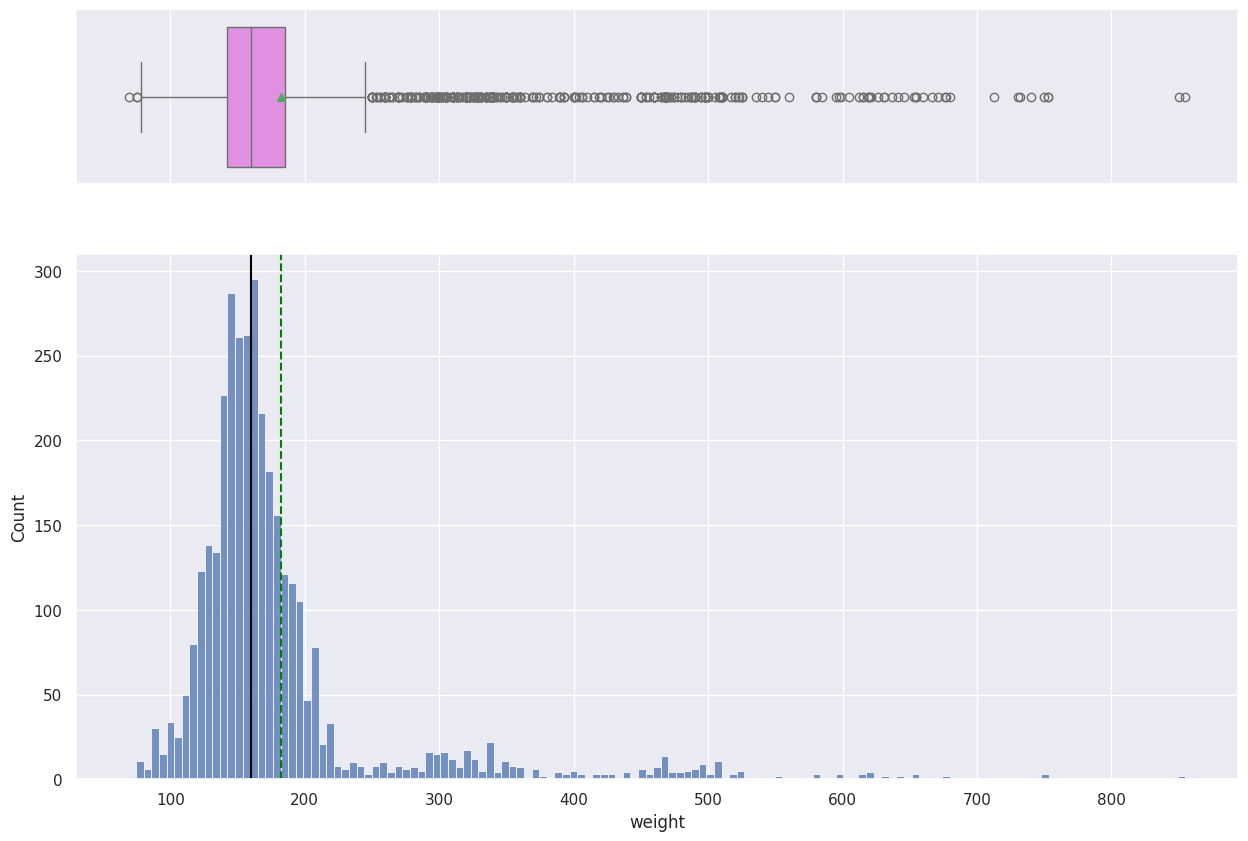

In [150]:
histogram_boxplot(df1, 'weight')

* The distribution for weight is right skewed with outliers above the maximum value.
* The median value is approximately 165 grams.

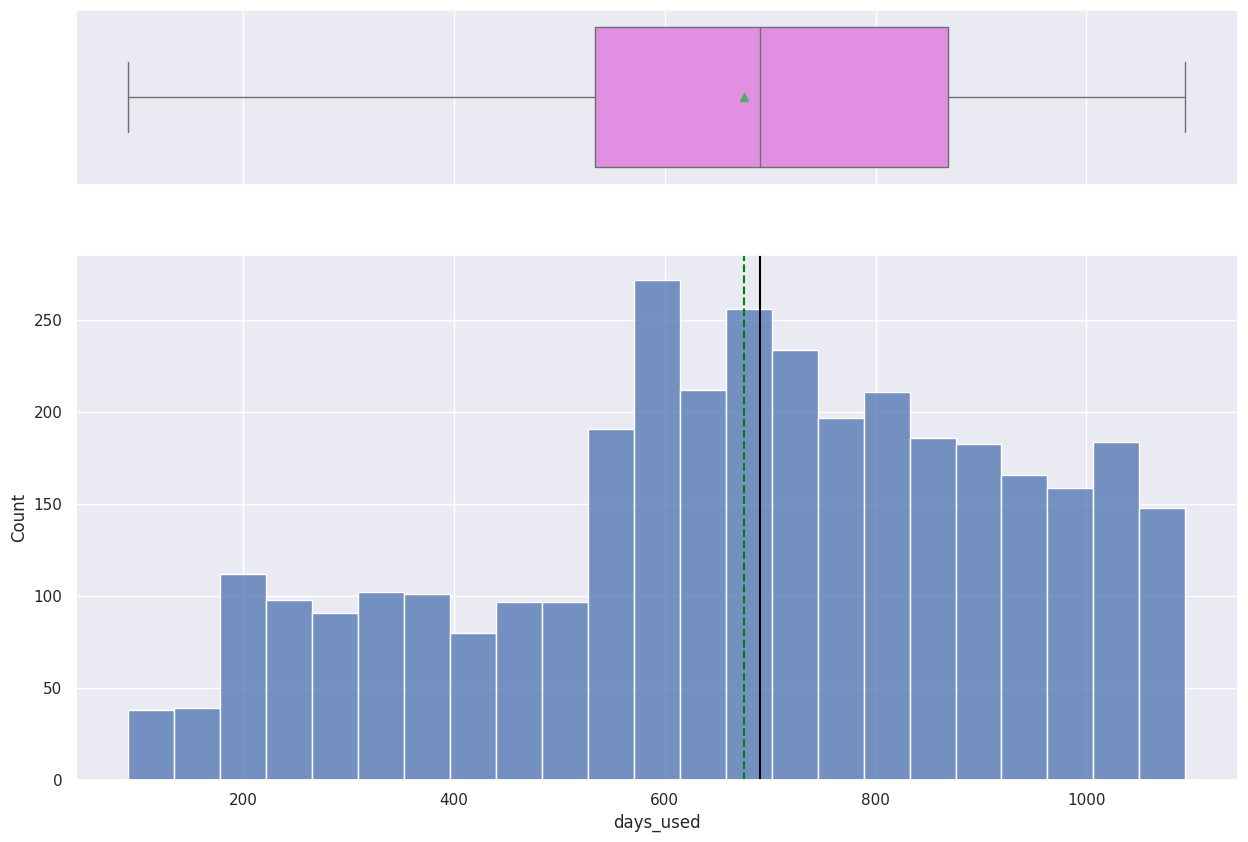

In [151]:
histogram_boxplot(df1, 'days_used')

* The distribution for the number of days used is slightly left skewed with no outliers.
* The median value is approximately 690 days.

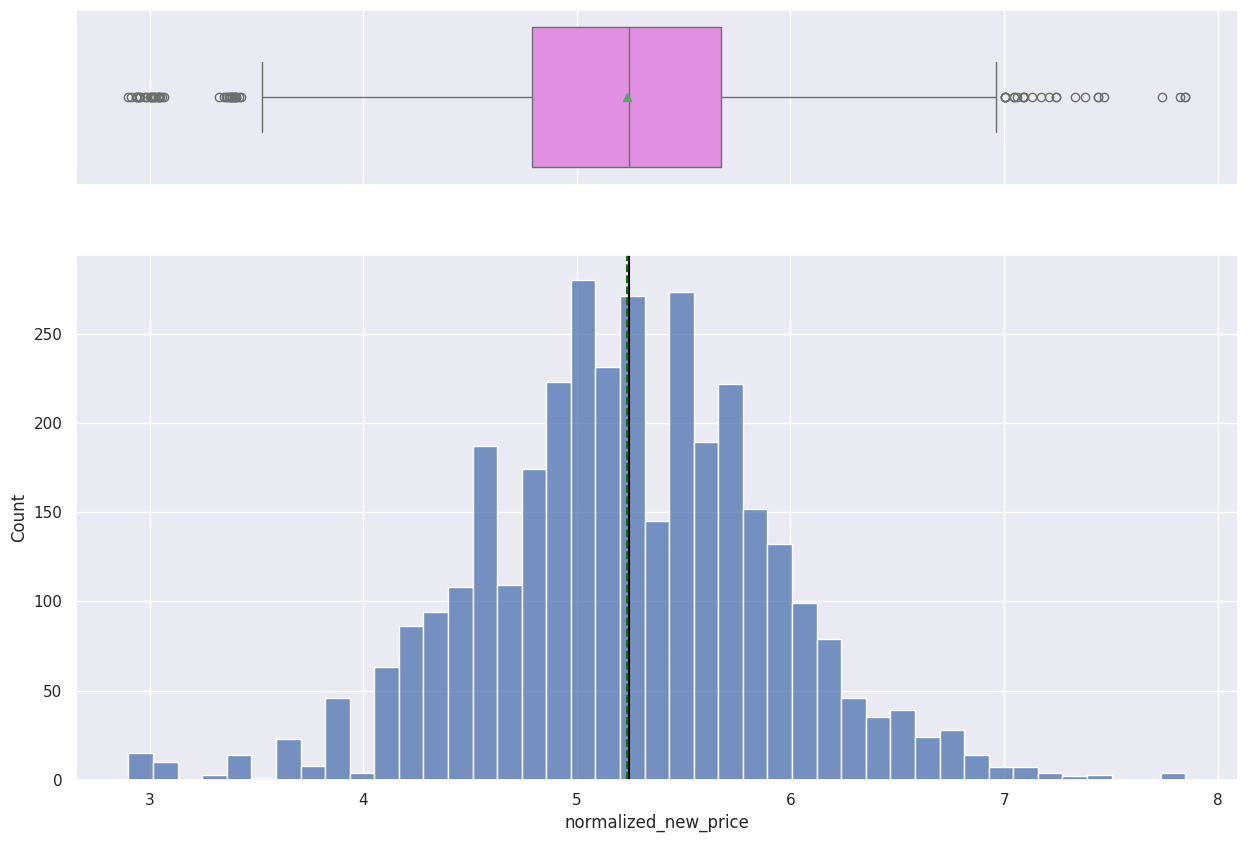

In [152]:
histogram_boxplot(df1, 'normalized_new_price')

* The distribution for normalized price of a new device is close to normally distributed with outliers on both ends of the distribution.
* The average price is approximately 5.3 in euros.

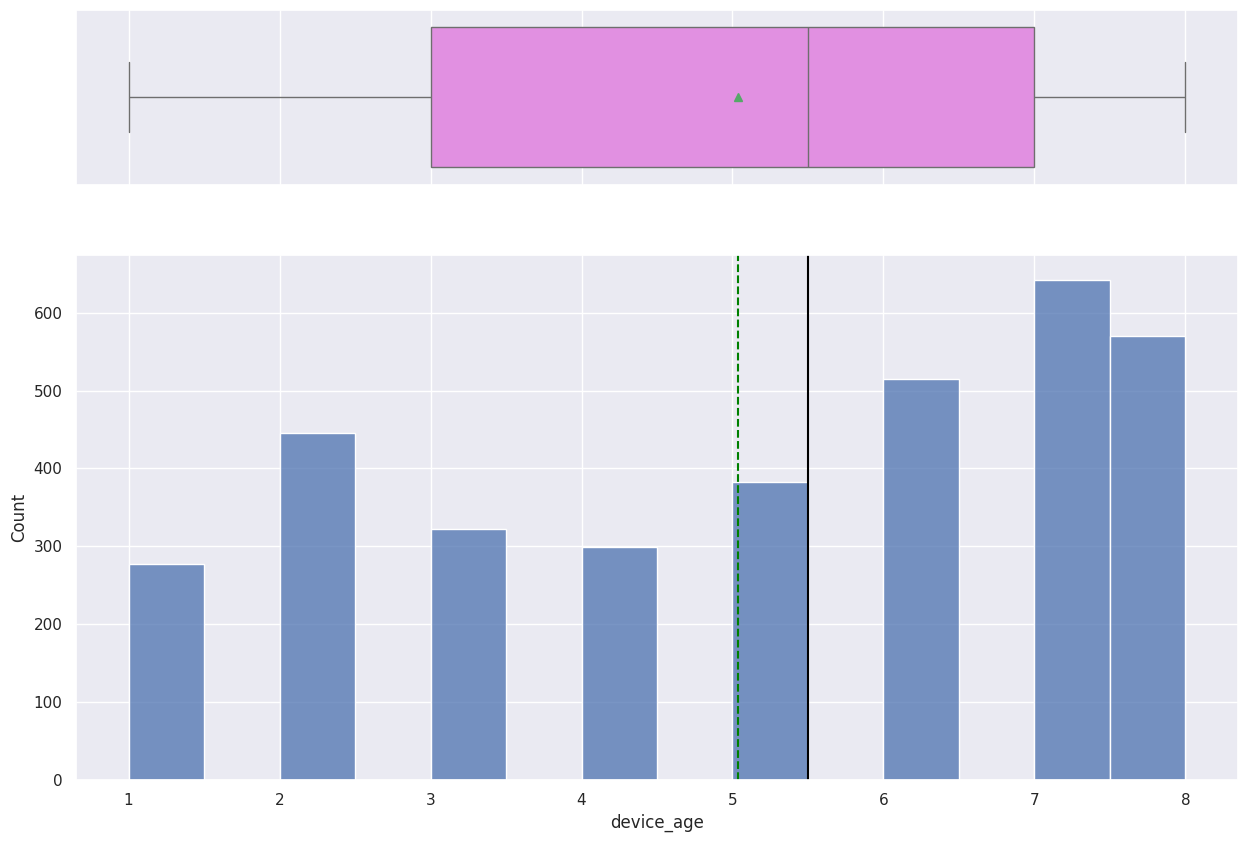

In [153]:
histogram_boxplot(df1, 'device_age')

* The distribution for the device age is left skewed with no outliers.
* The median age is 5.5 years.

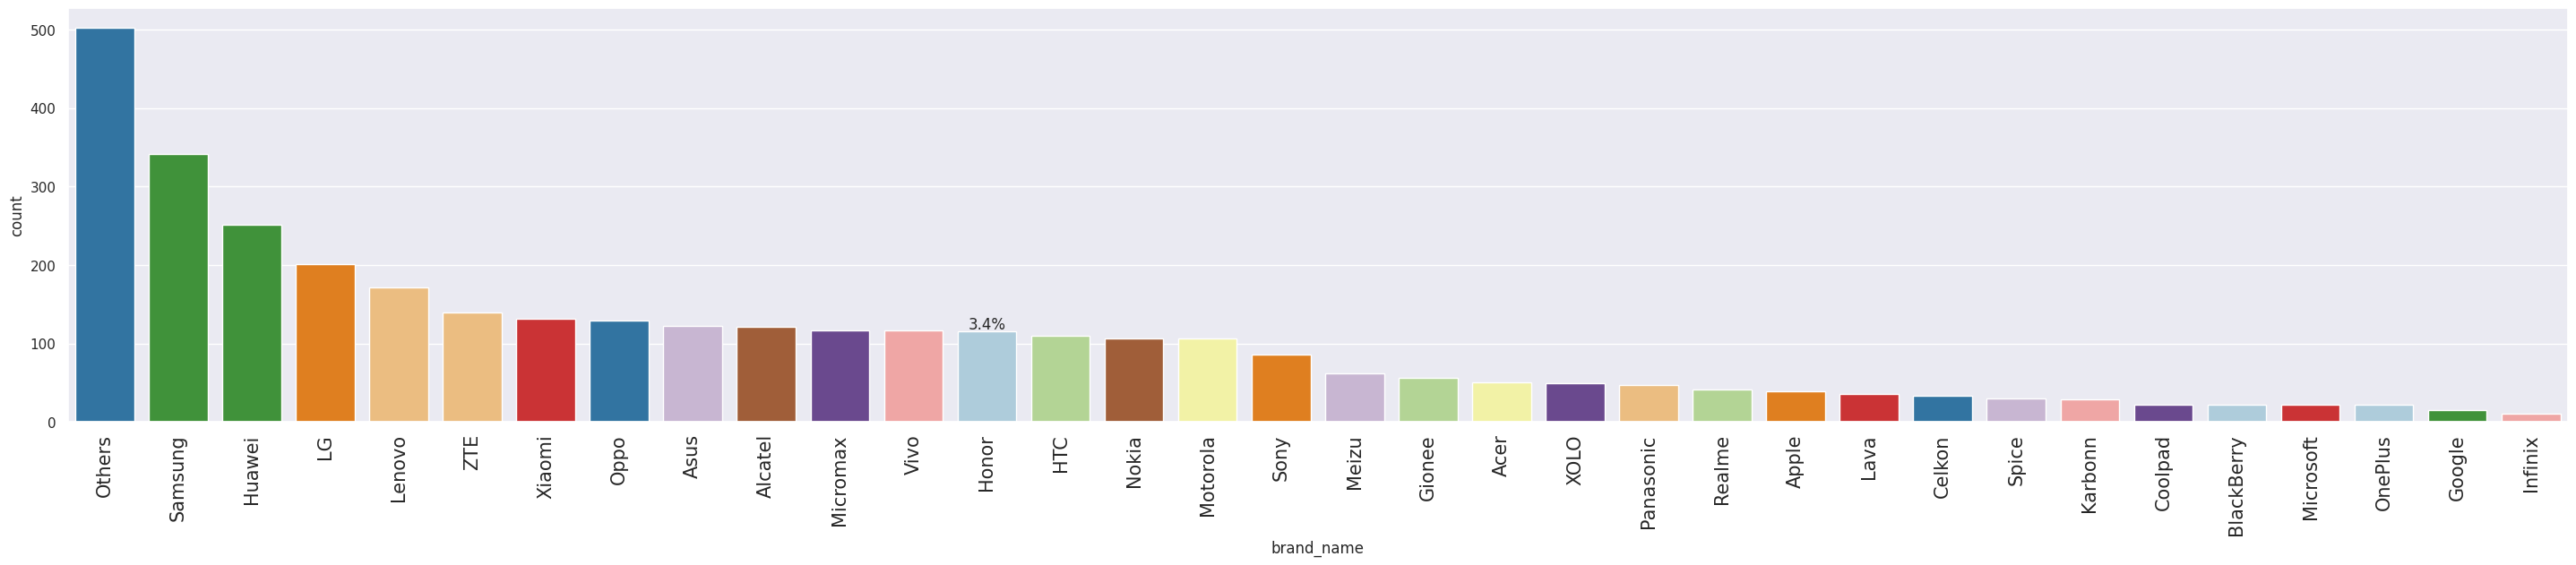

In [154]:
labeled_barplot(df1, 'brand_name', perc=True)

* Others have the highest percentage among the brands.
* Except for Others and Samsung, all the other brands have less than 10% of the total devices.

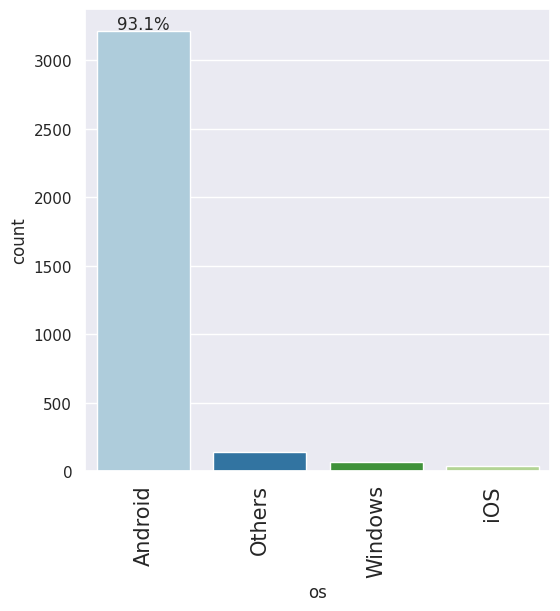

In [158]:
labeled_barplot(df1, 'os', perc=True)

* Androids have the highest percentage of the total devices at 93.1%.
* The other 3 os's have insignificant percentage of the total devices.

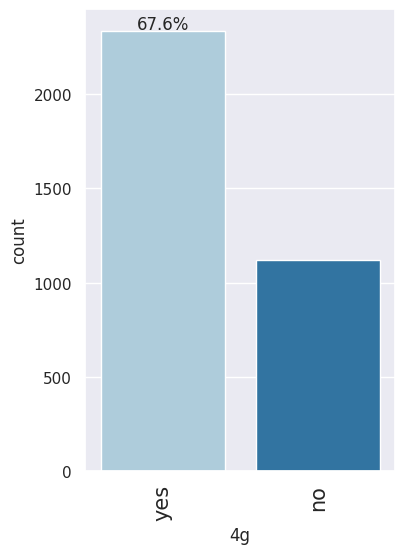

In [166]:
labeled_barplot(df1, '4g', perc=True)

* 67.6% of the devices offer 4g.

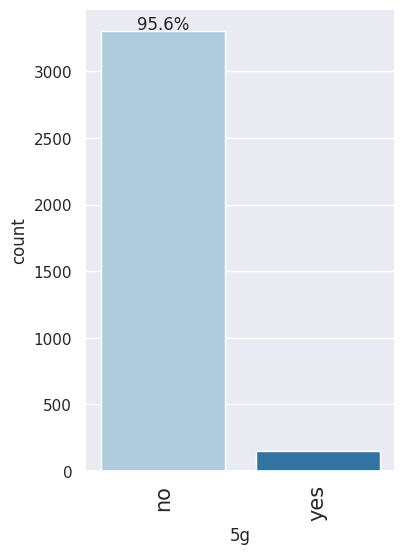

In [167]:
labeled_barplot(df1, '5g', perc=True)

* Only 4.4% of the devices offer 5g.

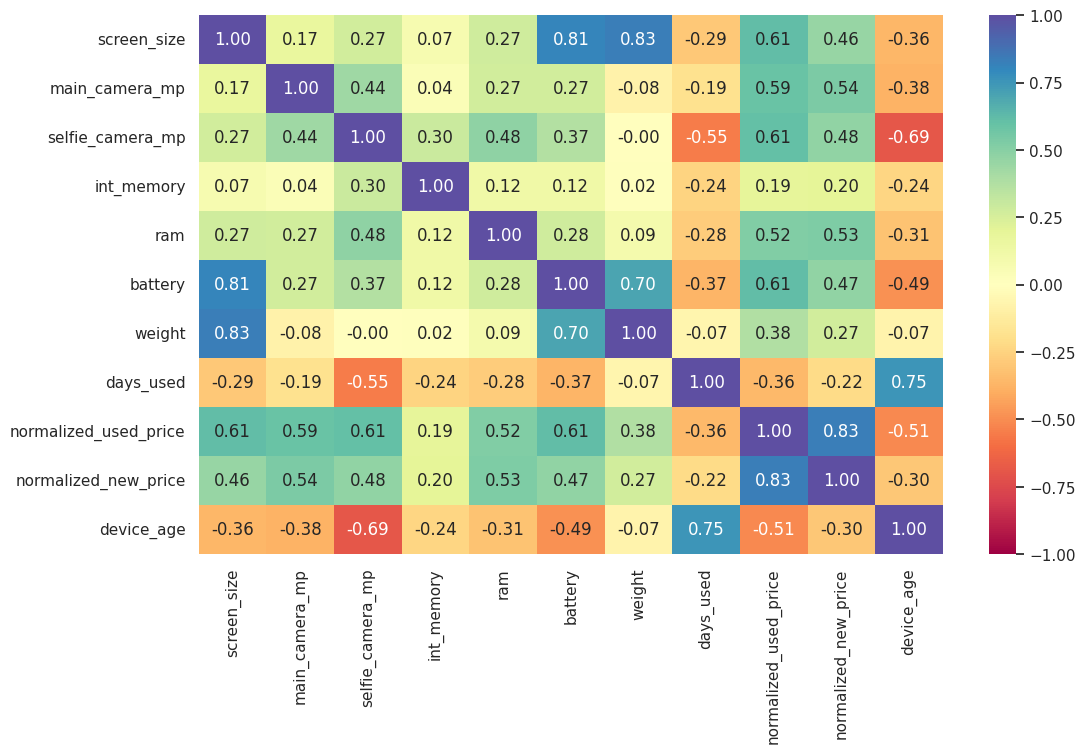

In [169]:
# creating a list of numerical columns
num_cols = df1.select_dtypes(include=np.number).columns.tolist()

# plotting a heat map to identify any correlations among different variables
plt.figure(figsize=(12, 7))
sns.heatmap(df1[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* The normalized used price is highly correlated with normalized new price.
* The normalized used price is relatively correlated with screen size, main camera mp, selfie camera mp, and battery.
* The screen size is highly correlated with battery and weight.
* Battery is relatively correlated with weight.
* The device age is highly correlated with days used.

## Model Building - Linear Regression

In [64]:
# building a linear regression model using OLS() function
olsmodel = sm.OLS(y_train, X_train).fit()

# printing the summary table
print(olsmodel.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     268.9
Date:                   Sun, 03 Nov 2024   Prob (F-statistic):               0.00
Time:                           16:50:51   Log-Likelihood:                 124.41
No. Observations:                   2417   AIC:                            -150.8
Df Residuals:                       2368   BIC:                             132.9
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


## Model Performance Check

1. **Adjusted. R-squared**: It reflects the fit of the model.
- Adjusted R-squared values generally range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
- In our case, the value for adj. R-squared is **0.842**, which is good.
2. ***const* coefficient**: It is the Y-intercept.
- It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the *const* coefficient.
- In our case, the value for `const` coefficient is **1.3160**
3. **Coefficient of a predictor variable**: It represents the change in the output Y due to a change in the predictor variable (everything else held constant).
- In our case, the coefficient of `ram` is **0.0232**.


## Model Performance Check

Let's check the performance of the model using different metrics.

- We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
- We will define a function to calculate MAPE and adjusted $R^2$.
    - The mean absolute percentagee error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.
- We will create a function which will print out all the above metrics in one go.

In [65]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1-r2) * (n-1) / (n - k - 1))

# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred) # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred) # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred)) # to compute RMSE
    mae = mean_absolute_error(target, pred) # to compute MAE
    mape = mape_score(target, pred) # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [66]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, X_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.229831,0.180234,0.844957,0.841748,4.324376


In [67]:
# checking model performance on test set (seen 30% data)
print("Testing Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, X_test, y_test)
olsmodel_test_perf

Testing Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.238452,0.184847,0.842354,0.834528,4.504914


###Observations

- The training $R^2$ is 0.84, so the model is not underfitting.
- The train and test RMSE and MAE are comparable, so the model is not overfitting either.
- MAE suggests that the model can predict price of used device within a mean error of 0.18 on the test data.
- MAPE of 4.5 on the test data means that we are able to predict within 4.5% of the price of used device.

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

We will be checking the following Linear Regression assumptions:

1. No Multicollinearity
2. Linearity of variables
3. Independence of error terms
4. Normality of error terms
5. No Heteroscedasticity

## Test for Multicollinearity

* Multicollinearity occurs when predictor variables in a regression model are correlated. This correlation is a problem because predictor variables should be independent. If the correlation between variables is high, it can cause problems when we fit the model and interpret the results. When we have multicollinearity in the linear model, the coefficients that the model suggests are unreliable.

* There are different ways of detecting (or testing) multicollinearity. One such way is by using the Variance Inflation Factor, or VIF.

* **Variance  Inflation Factor (VIF)**:  Variance inflation factors measure the inflation in the variances of the regression parameter estimates due to collinearities that exist among the predictors. It is a measure of how much the variance of the estimated regression coefficient $\beta_k$ is "inflated" by the existence of correlation among the predictor variables in the model.
    - If VIF is 1, then there is no correlation among the $k$th predictor and the remaining predictor variables, and hence, the variance of $\beta_k$ is not inflated at all.

* **General Rule of thumb**:
    - If VIF is between 1 and 5, then there is low multicollinearity.
    - If VIF is between 5 and 10, we say there is moderate multicollinearity.
    - If VIF is exceeding 10, it shows signs of high multicollinearity.

Let's define a function to check VIF.

In [68]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# defining a function to check VIF
def checking_vif(predictors):
    """
    Function to check VIF for multicollinearity
    """
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [69]:
checking_vif(X_train)

,feature,VIF
0,const,227.572607
1,screen_size,7.681213
2,main_camera_mp,2.284764
3,selfie_camera_mp,2.810915
4,int_memory,1.364051
5,ram,2.255201
6,battery,4.082894
7,weight,6.401092
8,days_used,2.660586
9,normalized_new_price,3.119377


* There are multiple columns with very high VIF values, indicating presence of strong multicollinearity.
* We will systematically drop numerical columns with VIF > 5.
* We will ignore the VIF values for dummy variables and the constant (intercept).

## Removing Multicollinearity

To remove multicollinearity

1. Drop every column one by one that has a VIF score greater than 5.
2. Look at the adjusted R-squared and RMSE of all these models.
3. Drop the variable that makes the least change in adjusted R-squared.
4. Check the VIF scores again.
5. Continue till you get all VIF scores under 5.

Let's define a function that will help us do this.

In [70]:
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Function to treat multicollinearity
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns with high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding the adjusted R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe with adjusted R-squared and RMSE values
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp


In [71]:
col_list = ["screen_size", "weight"]

res = treating_multicollinearity(X_train, y_train, col_list)
res

,col,Adj. R-squared after dropping col,RMSE after dropping col
0,screen_size,0.838482,0.234630
1,weight,0.838102,0.234906


- Since Adj. R-squared when screen_size is dropped is greater than that when weight is dropped, we will drop screen size column and check VIF again.

In [72]:
# dropping screen_size column
col_to_drop = "screen_size"
X_train2 = X_train.loc[:, ~X_train.columns.str.startswith(col_to_drop)]
X_test2 = X_test.loc[:, ~X_test.columns.str.startswith(col_to_drop)]

# checking VIF now
vif = checking_vif(X_train2)
print("VIF after dropping ", col_to_drop)
vif

VIF after dropping  screen_size


,feature,VIF
0,const,202.609416
1,main_camera_mp,2.281468
2,selfie_camera_mp,2.807499
3,int_memory,1.361978
4,ram,2.255200
5,battery,3.845847
6,weight,2.996224
7,days_used,2.648740
8,normalized_new_price,3.077340
9,device_age,4.730093


- We have dealt with multicollinearity in the data.
- Let's rebuild the model using the updated set of predictors variables.

In [73]:
olsmod1 = sm.OLS(y_train, X_train2).fit()
print(olsmod1.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.842
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     267.9
Date:                   Sun, 03 Nov 2024   Prob (F-statistic):               0.00
Time:                           16:50:53   Log-Likelihood:                 98.706
No. Observations:                   2417   AIC:                            -101.4
Df Residuals:                       2369   BIC:                             176.5
Df Model:                             47                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


### Interpreting the Regression Results:

4. **std err**: It reflects the level of accuracy of the coefficients.
    - The lower it is, the higher is the level of accuracy.

5. **P>|t|**: It is p-value.
    - For each independent feature, there is a null hypothesis and an alternative hypothesis. Here beta is the coefficient of the independent variable.
        - Null hypothesis: Independent feature is not significant (beta = 0)
        - Alternative hypothesis: Independent feature is that it is significant (beta != 0)
    - (P>|t|) gives the p-value for each independent feature to check that null hypothesis. We are considering 0.05 (5%) as significance level.
        - A p-value of less than 0.05 is considered to be statistically significant.

6. **Confidence Interval**: It represents the range in which our coefficients are likely to fall (with a likelihood of 95%).

**Observations**
- We can see that adj. R-squared has dropped from 0.842 to 0.838, which shows that the dropped columns did not have much effect on the model.
- As there is no multicollinearity, we can look at the p-values of predictor variables to check their significance.

### Dealing with high p-value variables
- Some of the dummy variables in the data have p-value > 0.05. So, they are not significant and we'll drop them.
- But sometimes p-values change after dropping a variable. So, we'll not drop all variables at once.
- Instead, we will do the following:
    - Build a model, check the p-values of the variables, and drop the column with the highest p-value.
    - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value.
    - Repeat the above two steps till there are no columns with p-value > 0.05.

**Note**: The above process can also be done manually by picking one variable at a time that has a high p-value, dropping it, and building a model again. But that might be a little tedious and using a loop will be more efficient.

In [74]:
# initial list of columns
predictors = X_train2.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, X_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        # dropping the variable with the maximum p-value
          cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'weight', 'normalized_new_price', 'device_age', 'brand_name_Karbonn', 'brand_name_Lenovo', 'brand_name_Xiaomi', 'os_Others', '4g_yes', '5g_yes']


In [75]:
X_train3 = X_train2[selected_features]
X_test3 = X_test2[selected_features]

In [76]:
olsmod2 = sm.OLS(y_train, X_train3).fit()
print(olsmod2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     1043.
Date:                   Sun, 03 Nov 2024   Prob (F-statistic):               0.00
Time:                           16:50:54   Log-Likelihood:                 78.326
No. Observations:                   2417   AIC:                            -130.7
Df Residuals:                       2404   BIC:                            -55.38
Df Model:                             12                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [77]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmod2_train_perf = model_performance_regression(olsmod2, X_train3, y_train)
olsmod2_train_perf


Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.234255,0.183167,0.838931,0.83806,4.40555


In [78]:
# checking model performance on the test set (seen 30% data)
print("Testing Performance\n")
olsmod2_test_perf = model_performance_regression(olsmod2, X_test3, y_test)
olsmod2_test_perf

Testing Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.241716,0.187668,0.838009,0.835951,4.579863


**Observations**

* Now no feature has p-value greater than 0.05, so we'll consider the features in *X_train3* as the final set of predictor variables and *olsmod2* as the final model to move forward with
* Now adjusted R-squared is 0.838, i.e., our model is able to explain ~84% of the variance
* The adjusted R-squared in *olsmod1* (where we considered the variables without multicollinearity) was 0.838
    * This shows that the variables we dropped were not affecting the model
* RMSE and MAE values are comparable for train and test sets, indicating that the model is not overfitting

Now we'll check the rest of the assumptions on olsmod2.
  
  2. **Linearity of variables**
  3. **independence of error terms**
  4. **Normality of error terms**
  5. **No Heteroscedsticity**

## TEST FOR LINEARITY AND INDEPENDENCE

**Why the test?**

* Linearity describes a straight-line relationship between two variables; predictor variables must have a linear relation with the dependent variable.
* The independence of the error terms (or residuals) is important. If the residuals are not independent, then the confidence intervals of the coefficient estimates will be narrower and make us incorrectly conclude a parameter to be statistically significant.

**How to check linearity and independence?**

- Make a plot of fitted values vs residuals.
- If they don't follow any pattern, then we say the model is linear and residuals are independent.
- Otherwise, the model is showing signs of non-linearity and residuals are not independent.

**How to fix if this assumption is not followed?**

* We can try to transform the variables and make the relationships linear.

In [80]:
# let's create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train # actual values
df_pred["Fitted Values"] = olsmod2.fittedvalues # predicted values
df_pred["Residuals"] = olsmod2.resid # residuals

df_pred.head()


,Actual Values,Fitted Values,Residuals
3026,4.087488,3.860554,0.226934
1525,4.448399,4.640231,-0.191832
1128,4.315353,4.279671,0.035681
3003,4.282068,4.239801,0.042267
2907,4.456438,4.485872,-0.029434


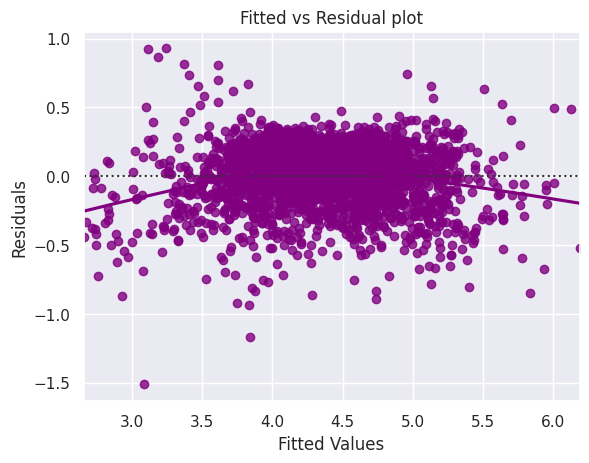

In [81]:
# let's plot the fitted values vs residuals
sns.residplot(
    data=df_pred,
    x="Fitted Values",
    y="Residuals",
    color="purple",
    lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

* The scatter plot shows the distribution of residuals (errors) vs fitted values (predicted values).

* If there exists any pattern in this plot, we consider it as signs of non-linearity in the data and a pattern means that the model doesn't capture non-linear effects.

* **We see no pattern in the plot above. Hence, the assumptions of linearity and independence are satisfied.**

### TEST FOR NORMALITY

**Why the test?**

* Error terms, or residuals, should be normally distributed. If the error terms are not normally distributed, confidence intervals of the coefficient estimates may become too wide or narrow. Once confidence interval becomes unstable, it leads to difficulty in estimating coefficients based on minimization of least squares. Non-normality suggests that there are a few unusual data points that must be studied closely to make a better model.

**How to check normality?**

* The shape of the histogram of residuals can give an initial idea about the normality.
* It can also be checked via a Q-Q plot of residuals. If the residuals follow a normal distribution, they will make a straight line plot, otherwise not.
* Other tests to check for normality includes the Shapiro-Wilk test.
    - Null hypothesis: Residuals are normally distributed
    - Alternate hypothesis: Residuals are not normally distributed

**How to fix if this assumption is not followed?**

* We can apply transformations like log, exponential, arcsinh, etc. as per our data.

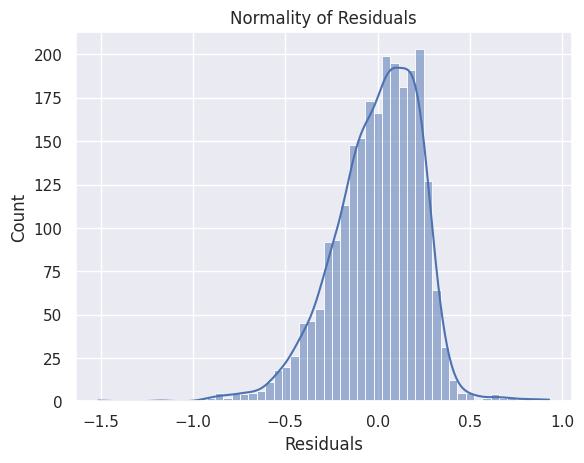

In [82]:
# let's visualize the distribution of residuals via histogram to determine the normality of residuals
sns.histplot(
    data=df_pred,
    x="Residuals",
    kde=True
)
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.title("Normality of Residuals")
plt.show()

* The histogram of residuals does have a bell shape.
* Let's check the Q-Q plot.

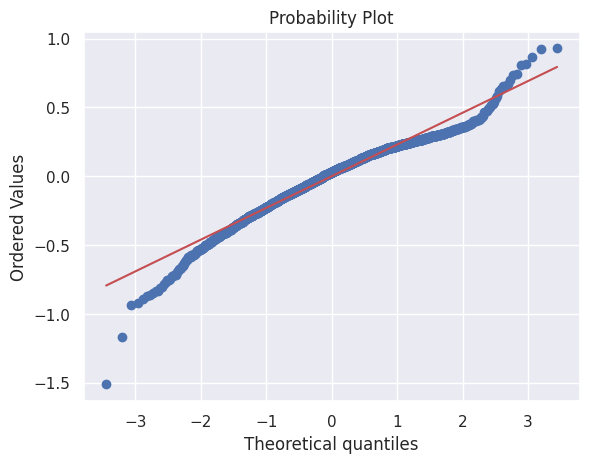

In [83]:
# plotting the Q-Q plot
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
pylab.show()


* The residuals more or less follow a straight line except for the tails.
* Let's check the results of the Shapiro-Wilk test.

In [84]:
# checking the shapiro-wilk test
from scipy.stats import shapiro

shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9680093763496329, pvalue=8.940968088160247e-23)

* Since p-value<0.05, the residuals are not normal as per the Shapiro-Wilk test.
* Strictly speaking, the residuals are not normal.
* However, as an approximation, we can accept this distribution as close to being normal.
* **So, the assumption is satisfied.**

### TEST FOR HOMOSCEDASTICITY

* **Homoscedascity**: If the variance of the residuals is symmetrically distributed across the regression line, then the data is said to be homoscedastic.

* **Heteroscedascity**: If the variance is unequal for the residuals across the regression line, then the data is said to be heteroscedastic.

**Why the test?**

* The presence of non-constant variance in the error terms results in heteroscedasticity. Generally, non-constant variance arises in presence of outliers.

**How to check for homoscedasticity?**

* The residual vs fitted values plot can be looked at to check for homoscedasticity. In the case of heteroscedasticity, the residuals can form an arrow shape or any other non-symmetrical shape.
* The goldfeldquandt test can also be used. If we get a p-value > 0.05 we can say that the residuals are homoscedastic. Otherwise, they are heteroscedastic.
    - Null hypothesis: Residuals are homoscedastic
    - Alternate hypothesis: Residuals have heteroscedasticity

**How to fix if this assumption is not followed?**

* Heteroscedasticity can be fixed by adding other important features or making transformations.

In [85]:
# checking for homoscedasticity via goldfeldquandt test
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], X_train3)
lzip(name, test)

[('F statistic', 1.0117272414330658), ('p-value', 0.42014346171682054)]

**Since p-value > 0.05, we can say that the residuals are homoscedastic. So, this assumption is satisfied.**

### Predictions on test data

Now that we have checked all the assumptions of linear regression and they are satisfied, let's go ahead with prediction.

In [86]:
# predictions on the test set
pred = olsmod2.predict(X_test3)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
1995,4.566741,4.375500
2341,3.696103,3.996291
1913,3.592093,3.638482
688,4.306495,4.090978
650,4.522115,5.181150
2291,4.259294,4.386024
40,4.997685,5.439584
1884,3.875359,4.045659
2538,4.206631,4.062298
45,5.380450,5.219654


* We can observe that our model has returned pretty good prediction results, and the actual and predicted values are comparable.

## Final Model

Let's recreate the final model and print its summary to gain insights.

In [91]:
# creating a copy of the final train and test data
X_train_final = X_train3.copy()
X_test_final = X_test3.copy()

In [170]:
# creating the final model and printing its summary
olsmodel_final = sm.OLS(y_train, X_train_final).fit()
print(olsmodel_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     1043.
Date:                   Sun, 03 Nov 2024   Prob (F-statistic):               0.00
Time:                           20:13:04   Log-Likelihood:                 78.326
No. Observations:                   2417   AIC:                            -130.7
Df Residuals:                       2404   BIC:                            -55.38
Df Model:                             12                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [89]:
# checking model performance on the train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, X_train_final, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.234255,0.183167,0.838931,0.83806,4.40555


In [92]:
# checking the model performance on test set (seen 30% data)
print("Testing Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, X_test_final, y_test
)
olsmodel_final_test_perf

Testing Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.241716,0.187668,0.838009,0.835951,4.579863


* The model is able to explain ~84% of the variation in the data.

* The train and test RMSE and MAE are low and comparable. So, our model is not suffering from overfitting.

* The MAPE on the test set suggests we can predict within 4.6% of the price of the used device.

* Hence, we can conclude the model *olsmodel_final* is good for prediction as well as inference purposes.

## Actionable Insights and Recommendations

1.	The model is able to explain ~84% of the variation in the data and within 4.6% of the prices of used devices on the test data, which is good.
    - **This indicates that the model is good for prediction as well as inference purposes.**

2.	If the price of a new device increases by one unit, then the price of the used device increases by 0.4347 units, all other variables held constant.
    - **Since the price of a used device are moderately correlated with the prices of new devices, we recommend that ReCell adjust used device prices by offering competitive pricing when a new model is released in the market, targeting a customer segment who may be attracted to the affordability of used devices.**

3.	If the resolution of rear camera increases by one unit, then the price of the used device increases by 0.0210 units, all other variables held constant.
    - **ReCell can differentiate prices of used devices based on the resolution of rear camera as the customers seem to pay a premium for devices with higher resolution.**

4.	If the amount of ram increases by one unit, then the price of the used device increases by 0.0212 units, all other variables held constant.
    - **ReCell can differentiate prices of used devices based on the size of ram as the customers seem to pay a premium for devices with larger ram size.**

5.	If the age of the device increases by one unit, then the price of the used device decreases by 0.0297 units, all other variables held constant.
    - **Since older devices carry lower resale values, we recommend that ReCell offer competitive pricing for older devices to customer who are price-sensitive.**

6.	The price of the used device for Karbonn will be 0.1219 units greater than that for Alcatel.
    - **Since customers are willing to pay premium prices for Karbonn vs. Alcatel, we recommend that ReCell charge higher price for Karbonn than for Alcatel.**

7.	The price of the used device running other os will be 0.1296 units less than the used device running android.
    - **Since devices running on other os command lower prices than devices running android operating systems, we recommend that ReCell consider reducing the stock of devices with other os and offering low prices for those devices based on the customers' lack of perceived value in them.**



___